Relative L2 error (truncated SVD): 7.359e-12
Predicted u(0) ≈ -1.0000, Target a1 = -1.0
Predicted u(1) ≈ -1.5000, Target a2 = -1.5
Expected u_true(0) = -1.0000, u_true(1) = -1.5000
Value for c = 0.067


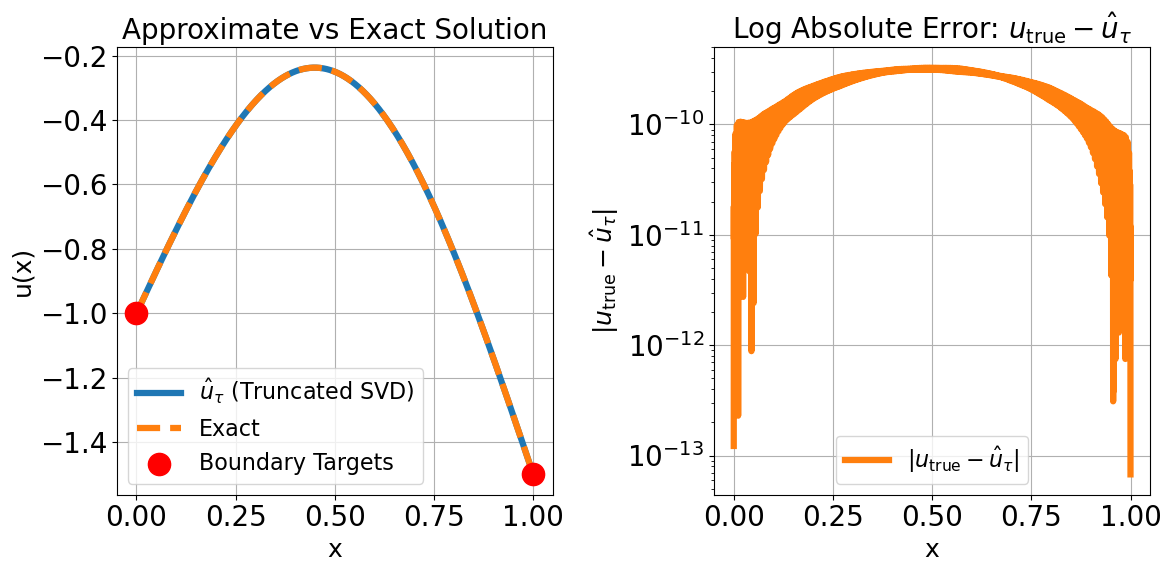

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from numpy.linalg import svd, lstsq, norm

# ----------------------------
# Parameters
# ----------------------------
N = 2000
zeta = 2
M = zeta * N
tau = 1e-15
T = 4
c = np.pi/(T *np.sqrt(2 * np.log(1 + tau**(-2))))
b = c * N

beta = 3e5

# User-defined Dirichlet boundary conditions
a1 = -1.0    # u(0) = a1
a2 = -1.5    # u(1) = a2

# ----------------------------
# Domain and Source Function
# ----------------------------
x = np.linspace(0, 1, M)
lower_a = 0.0
upper_b = 1.0 
L = 0.5 * (upper_b -  lower_a)
q = 0.5 * (lower_a  + upper_b) 

centers = np.linspace(q - T * L, q + T * L, N)
dx = x[1] - x[0]

# Exact solution and RHS
u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
f = lambda x: np.pi**2 * np.sin(np.pi * x)
rhs = f(x)

# ----------------------------
# Numba-accelerated RBF kernels
# ----------------------------
@njit
def rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out

# ----------------------------
# Build RBF matrices
# ----------------------------
Phi_raw = rbf(x, centers, b)
Phi = Phi_raw / np.sqrt(N)
D2Phi = d2rbf(x, centers, b) / np.sqrt(N)

A1 = D2Phi.T @ D2Phi * dx
r_vec = -D2Phi.T @ rhs * dx

# ----------------------------
# Boundary Penalty Term (Fixed Sign)
# ----------------------------
x_bdry = np.array([0.0, 1.0])
Phi_bdry = rbf(x_bdry, centers, b) / np.sqrt(N)
g_bdry = u_true(x_bdry)

A3 = np.sqrt(beta / 2) * Phi_bdry
r3 = np.sqrt(beta / 2) * g_bdry

# Combine full system
A_total = A1 + A3.T @ A3
b_total = r_vec + A3.T @ r3

# ----------------------------
# Solve using SVD
# ----------------------------
U, S, VT = svd(A_total)
S_inv = np.where(S > tau * np.max(S), 1/S, 0)
w_tau = VT.T @ (S_inv * (U.T @ b_total))

# 1. Compute the threshold
threshold = tau * S.max()

# 2. Find all i for which S[i] > threshold
retained = np.where(S > threshold)[0]

# 3. The number of retained modes is k
k = retained.size

# 4. If you want the largest retained index (0‐based):
k_max_index = retained.max()  # so modes 0..k_max_index are kept

# ------------------------------------------------------------------ #
# 4.  direct least-squares solution  (w*)
# ------------------------------------------------------------------ #
w_star, *_ =  np.linalg.lstsq(A_total, b_total, rcond = tau)


# Additional diagnostic: |U^T b| / tau
proj_diag = k * np.abs(U.T @ b_total) / tau

# ----------------------------
# Evaluate
# ----------------------------
u_hat_tau = Phi @ w_tau
u_hat = Phi @ w_star
u_exact = u_true(x)

rel_L2_err = np.linalg.norm(u_hat_tau - u_exact) / np.linalg.norm(u_exact)**2
print(f"Relative L2 error (truncated SVD): {rel_L2_err:.3e}")
print(f"Predicted u(0) \u2248 {u_hat_tau[0]:.4f}, Target a1 = {a1}")
print(f"Predicted u(1) \u2248 {u_hat_tau[-1]:.4f}, Target a2 = {a2}")
print(f"Expected u_true(0) = {u_exact[0]:.4f}, u_true(1) = {u_exact[-1]:.4f}")
print(f"Value for c = {c:.3f}")

# ----------------------------
# Plot 2x2 Figures
# ----------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 20
legend_fontsize = 16
linewidth = 4.5


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 3.5,
    "lines.markersize": 16,
    "grid.alpha": 0.1,
     "figure.dpi": 300
})


# Top Left: Solution comparison
axs[0].plot(x, u_hat_tau, label=r'$\hat{u}_{\tau}$ (Truncated SVD)', linewidth=linewidth)
axs[0].plot(x, u_exact, '--', label='Exact', linewidth=linewidth)
axs[0].scatter(x_bdry, g_bdry, color='red', label='Boundary Targets', zorder=5)
axs[0].set_title('Approximate vs Exact Solution', fontsize=title_fontsize)
axs[0].set_xlabel('x', fontsize=label_fontsize)
axs[0].set_ylabel('u(x)', fontsize=label_fontsize)
axs[0].tick_params(labelsize=tick_fontsize)
axs[0].legend(fontsize=legend_fontsize)
axs[0].grid(True)

# Top Right: Error between exact and truncated SVD solution
axs[1].plot(x, np.abs(u_exact - u_hat_tau), label=r'$|u_{\mathrm{true}} - \hat{u}_{\tau}|$', linewidth=linewidth, color = 'tab:orange')
axs[1].set_yscale('log')
axs[1].set_title(r'Log Absolute Error: $u_{\mathrm{true}} - \hat{u}_{\tau}$', fontsize=title_fontsize)
axs[1].set_xlabel('x', fontsize=label_fontsize)
axs[1].set_ylabel(r'$|u_{\mathrm{true}} - \hat{u}_{\tau}|$', fontsize=label_fontsize)
axs[1].tick_params(labelsize=tick_fontsize)
axs[1].legend(fontsize=legend_fontsize)
axs[1].grid(True)

# Bottom Left: Difference between full and truncated SVD
#axs[1, 0].plot(x, np.abs(u_hat - u_hat_tau), label=r'$|\hat{u} - \hat{u}_{\tau}|$', linewidth=linewidth)
#axs[1, 0].set_yscale('log')
#axs[1, 0].set_title(r'Log Absolute Error: $\hat{u} - \hat{u}_{\tau}$', fontsize=title_fontsize)
#axs[1, 0].set_xlabel('x', fontsize=label_fontsize)
#axs[1, 0].set_ylabel(r'$|\hat{u} - \hat{u}_{\tau}|$', fontsize=label_fontsize)
#axs[1, 0].tick_params(labelsize=tick_fontsize)
#axs[1, 0].legend(fontsize=legend_fontsize)
#axs[1, 0].grid(True)

# Bottom Right: Difference in weights
#axs[1, 1].plot(np.abs(w_star - w_tau) * tau , label=r'$|w^* - w_{\tau}|$', linewidth=linewidth, color = 'black')
#axs[1, 1].plot(proj_diag, '--', label=r'$k|U^T b|/\tau$', linewidth=linewidth, color = 'red')
#axs[1, 1].set_yscale('log')
#axs[1, 1].set_title(r'Magnitutde: $|w^* - w_{\tau}|$ and $k |U^T b|/\tau$', fontsize=title_fontsize)
#axs[1, 1].set_xlabel('Index', fontsize=label_fontsize)
#axs[1, 1].set_ylabel('Magnitude', fontsize=label_fontsize)
#axs[1, 1].tick_params(labelsize=tick_fontsize)
#axs[1, 1].legend(fontsize=legend_fontsize)
#axs[1, 1].grid(True)

plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig1_poisson.png')


# Benchmark for Comparison Methods

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit
import time
import torch
import torch.nn as nn
import torch.optim as optim
import tracemalloc
import seaborn as sns
import pandas as pd


# ----------------------------
# Numba-accelerated RBF kernels
# ----------------------------
@njit
def rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out


# ----------------------------
# Benchmark Wrapper with Memory Tracking
# ----------------------------
def benchmark_with_memory(solver, N, a1, a2):
    tracemalloc.start()
    result = solver(N, a1, a2)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result + (peak / 1024**2,)  # Return in MB

# ----------------------------
# Solver Function
# ----------------------------
def benchmark_solver(N, a1, a2, c=0.067, zeta = 2, T=4, beta=3e5, tau=1e-15, jitter = False, jitter_scale = 0.001):
    M = zeta * N
    b = c * (N**(9/10)) 
    x = np.linspace(0, 1, M)
    lower_a = 0.0
    upper_b = 1.0
    L = 0.5 * (upper_b -  lower_a)
    q = 0.5 * (lower_a  + upper_b) 
    
    centers = np.linspace(q - T*L, q + T*L, N)
    if jitter:
        noise = np.random.normal(0.01,jitter_scale, size=N)
        centers += noise
        # keep centers inside the expanded interval, not [0,1]
        centers = np.clip(centers, q - T*L, q + T*L)
        
    dx = x[1] - x[0]

    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    rhs = f(x)

    Phi_raw = rbf(x, centers, b)
    Phi = Phi_raw / np.sqrt(N)
    D2Phi = d2rbf(x, centers, b) / np.sqrt(N)

    A1 = D2Phi.T @ D2Phi * dx
    r_vec = -D2Phi.T @ rhs * dx

    x_bdry = np.array([0.0, 1.0])
    Phi_bdry = rbf(x_bdry, centers, b) / np.sqrt(N)
    g_bdry = u_true(x_bdry)

    A3 = np.sqrt(beta / 2) * Phi_bdry
    r3 = np.sqrt(beta / 2) * g_bdry

    A_total = A1 + A3.T @ A3
    b_total = r_vec + A3.T @ r3

    start = time.time()
    U, S, VT = svd(A_total)
    S_inv = np.where(S > tau * np.max(S), 1/S, 0)
    w = VT.T @ (S_inv * (U.T @ b_total))
    elapsed = time.time() - start

    u_pred = Phi @ w
    u_exact = u_true(x)
    rel_L2_err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact) ** 2

    return N, rel_L2_err, elapsed

# ----------------------------
# Benchmark Loop
# ----------------------------
# Spectral Method Solver (Chebyshev Collocation)
# ----------------------------
# Spectral Method Solver (Chebyshev Collocation)  FIXED
# Solves: -u''(x) = f(x) on [0,1], u(0)=a1, u(1)=a2
# Exact:  u(x) = sin(pi x) + (a2-a1)x + a1
# ----------------------------
from numpy.polynomial import Chebyshev as Ch

def spectral_solver(N, a1, a2):
    """
    Stable Chebyshev coefficient-space Poisson solve on [0,1]:
        -u''(x) = f(x),  u(0)=a1, u(1)=a2
    Test RHS: f(x)=pi^2 sin(pi x)  => exact: u(x)=sin(pi x)+(a2-a1)x+a1
    Returns: (num_nodes, rel_L2_error, elapsed_seconds)
    """
    # Chebyshev nodes on [-1,1] and map to [0,1]
    xi = np.cos(np.pi * np.arange(N + 1) / N)
    x  = 0.5 * (xi + 1.0)

    f = lambda x: (np.pi**2) * np.sin(np.pi * x)
    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    # In ξ-coordinates: x=(ξ+1)/2, and u_xx = 4 u_ξξ, so  -4 u_ξξ(ξ) = f((ξ+1)/2)
    h_vals = f(0.5*(xi + 1.0))

    # Fit h(ξ) in Chebyshev basis (degree N)
    # Using exact nodes avoids overfitting; fit is essentially interpolation here.
    H = Ch.fit(xi, h_vals, deg=N, domain=[-1,1])

    # u''(ξ) = -h(ξ)/4 in ξ; integrate twice
    Udd = (-0.25) * H
    U0  = Udd.integ().integ()  # two integrations add two free constants later

    # Enforce u(-1)=a1 and u(1)=a2 via linear combination c0 + c1*ξ:
    u_m1 = U0(-1.0)  # value at ξ=-1
    u_p1 = U0( 1.0)  # value at ξ= 1
    c0 = 0.5 * ((a1 + a2) - (u_m1 + u_p1))
    c1 = 0.5 * ((a2 - a1) - (u_p1 - u_m1))

    U = U0 + Ch([c0, c1])  # add c0*T0 + c1*T1

    # Evaluate and measure error
    start = time.time()
    u_pred = U(xi)  # values at Chebyshev nodes in ξ, which map to x
    elapsed = time.time() - start

    u_ex = u_true(x)
    rel_err = np.linalg.norm(u_pred - u_ex) / np.linalg.norm(u_ex)
    return N, rel_err, elapsed



# ----------------------------
# Galerkin Solver (2 layers)
# "Galerkin"   FIXED
# Solves: -u''(x) = f(x) on [0,1], u(0)=a1, u(1)=a2
# ----------------------------
def galerkin_solver(N, a1, a2):
    # Use M=N+1 grid points including both endpoints
    M = N + 1
    x = np.linspace(0.0, 1.0, M)
    dx = x[1] - x[0]

    f = lambda x: (np.pi**2) * np.sin(np.pi * x)  # for -u'' = f
    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    # Interior unknowns: indices 1..M-2  (total M-2 unknowns)
    m = M - 2
    A = np.zeros((m, m))
    b = -f(x[1:-1])  # D2 u = -f  with D2 ≈ (u_{i-1}-2u_i+u_{i+1})/dx^2

    # Build tri-diagonal for second derivative
    diag = -2.0 * np.ones(m)
    off  =  1.0 * np.ones(m - 1)
    A[np.arange(m), np.arange(m)] = diag
    A[np.arange(m - 1), np.arange(1, m)] = off
    A[np.arange(1, m), np.arange(m - 1)] = off
    A /= dx**2

    # Move Dirichlet boundaries to RHS
    b[0] -= (1.0 / dx**2) * a1
    b[-1] -= (1.0 / dx**2) * a2

    start = time.time()
    u_interior = np.linalg.solve(A, b)
    elapsed = time.time() - start

    u_pred = np.zeros(M)
    u_pred[0] = a1
    u_pred[-1] = a2
    u_pred[1:-1] = u_interior

    u_exact = u_true(x)
    err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    return M, err, elapsed


# ----------------------------
# Neural Network Solver
# ----------------------------
class ShallowNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.net(x)

def nn_solver(N, a1, a2, epochs=2000, lr=0.01):
    x = np.linspace(0, 1, N).reshape(-1, 1)
    x_tensor = torch.tensor(x, dtype=torch.float32)
    x_tensor.requires_grad = True

    model = ShallowNN()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    def f(x): return np.pi**2 * np.sin(np.pi * x)
    target = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    start = time.time()
    for _ in range(epochs):
        optimizer.zero_grad()
        u = model(x_tensor)
        du = torch.autograd.grad(u, x_tensor, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        d2u = torch.autograd.grad(du, x_tensor, grad_outputs=torch.ones_like(du), create_graph=True)[0]
        loss_interior = ((d2u + (np.pi**2) * torch.sin(np.pi * x_tensor))**2).mean()
        loss_bc = (model(torch.tensor([[0.0]])).squeeze() - a1)**2 + (model(torch.tensor([[1.0]])).squeeze() - a2)**2
        loss = loss_interior + loss_bc
        loss.backward()
        optimizer.step()
    elapsed = time.time() - start

    with torch.no_grad():
        u_pred = model(x_tensor).numpy().squeeze()
    u_exact = target(x.squeeze())
    err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    return N, err, elapsed



# ----------------------------
# Finite-Difference Solver (2nd-order central)
# Solves: -u''(x) = f(x) on [0,1], u(0)=a1, u(1)=a2
# Returns: (M, rel_L2_error, elapsed_seconds) with M=N+1 grid points
# ----------------------------
def finite_difference_solver(N, a1, a2):
    # Use M = N+1 grid points including endpoints
    M = N + 1
    x = np.linspace(0.0, 1.0, M)
    h = x[1] - x[0]

    f = lambda x: (np.pi**2) * np.sin(np.pi * x)  # RHS for -u''=f
    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    # Interior unknowns: indices 1..M-2 -> size m
    m = M - 2
    A = np.zeros((m, m))
    b = -f(x[1:-1])  # because (u_{i-1}-2u_i+u_{i+1})/h^2 = -f(x_i)

    # Tridiagonal Laplacian
    A[np.arange(m), np.arange(m)] = -2.0
    A[np.arange(m - 1), np.arange(1, m)] = 1.0
    A[np.arange(1, m), np.arange(m - 1)] = 1.0
    A /= h**2

    # Dirichlet BC contributions to RHS
    b[0]  -= a1 / h**2
    b[-1] -= a2 / h**2

    # Solve
    start = time.time()
    u_interior = np.linalg.solve(A, b)
    elapsed = time.time() - start

    # Assemble full solution
    u_pred = np.zeros(M)
    u_pred[0], u_pred[-1] = a1, a2
    u_pred[1:-1] = u_interior

    # Error (relative L2)
    u_exact = u_true(x)
    err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact) ** 2
    return M, err, elapsed



In [4]:
# ----------------------------
# Run All Solvers
# ----------------------------
N_values = [8, 16, 32,64,128,256, 512, 1024, 2048]
a1, a2 = -1.0, -1.5
T = 4
tau = 1e-15
c_formula = np.pi/ (T * np.sqrt(2 * np.log(1 + tau **(-2))))
results_rbf = [benchmark_solver(N, a1, a2, c = c_formula, T = 4) for N in N_values]
results_gal = [galerkin_solver(N, a1, a2) for N in N_values]
results_nn  = [nn_solver(N, a1, a2) for N in N_values]
#results_spec = [spectral_solver(N, a1, a2) for N in N_values]
results_fd = [finite_difference_solver(N, a1, a2) for N in N_values]


results_rbf = [benchmark_with_memory(benchmark_solver, N, a1, a2) for N in N_values]
results_gal = [benchmark_with_memory(galerkin_solver, N, a1, a2) for N in N_values]
results_nn  = [benchmark_with_memory(nn_solver, N, a1, a2) for N in N_values]
#results_spec = [benchmark_with_memory(spectral_solver, N, a1, a2) for N in N_values]
results_fd = [benchmark_with_memory(finite_difference_solver, N, a1, a2) for N in N_values]




# Optional: Print results
df_rbf = pd.DataFrame(results_rbf, columns=['N', 'RBF Error', 'RBF Time', 'RBF Memory (MB)'])
df_gal = pd.DataFrame(results_gal, columns=['N', 'Galerkin Error', 'Galerkin Time', 'Galerkin Memory (MB)'])
df_nn  = pd.DataFrame(results_nn, columns=['N', 'NN Error', 'NN Time', 'NN Memory (MB)'])
#df_spec = pd.DataFrame(results_spec, columns=['N', 'Spectral Error', 'Spectral Time', 'Spectral Memory (MB)'])
df_fd = pd.DataFrame(results_fd, columns=['N', 'FD Error', 'FD Time', 'FD Memory (MB)'])
#df_all = pd.concat([df_rbf.set_index('N'), df_gal.set_index('N'), df_nn.set_index('N'), df_spec.set_index('N'), df_fd.set_index('N')], axis=1)
df_all = pd.concat([df_rbf.set_index('N'), df_gal.set_index('N'), df_nn.set_index('N'), df_fd.set_index('N')], axis=1)



In [5]:
# =========================
# Helper: convergence order
# =========================
def local_orders(Ns, errs):
    Ns = np.asarray(Ns, dtype=float)
    errs = np.asarray(errs, dtype=float)
    # keep only strictly positive finite errors
    mask = np.isfinite(errs) & (errs > 0)
    Ns = Ns[mask]
    errs = errs[mask]
    if len(Ns) < 2:
        return Ns, np.array([]), np.nan
    # p_i between successive pairs
    p = -np.log(errs[1:] / errs[:-1]) / np.log(Ns[1:] / Ns[:-1])
    p_bar = np.mean(p)
    return Ns[1:], p, p_bar

# Extract error series
E_rbf   = [r[1] for r in results_rbf]
E_gal   = [r[1] for r in results_gal]
E_nn    = [r[1] for r in results_nn]
#E_spec  = [r[1] for r in results_spec]
E_fd    = [r[1] for r in results_fd]

In [6]:
# ----------------------------
# Jitter RBF Boxplot Experiments# ----------------------------
#max_runs = 20
#Ns_jitter = [100, 500, 1000, 2000]
#a1, a2 = -1.0, -1.5
#jitter_results = {N: [] for N in Ns_jitter}

#for N in Ns_jitter:
#    for _ in range(max_runs):
#        _, err, _, _ = benchmark_with_memory(lambda N, a1, a2: benchmark_solver(N, a1, a2, c = 0.067,T = 4, jitter=True), N, a1, a2)
#        jitter_results[N].append(err)


# =========================
# Fig 2: Run-to-run spread
# =========================
# Build violin DataFrame (expects Ns_jitter, jitter_results to be defined)
#violin_data = []
#for N in Ns_jitter:
#    for val in jitter_results[N]:
#        violin_data.append({'N': N, 'Error': val})
#df_violin = pd.DataFrame(violin_data)

#plt.figure(figsize=(9, 7.5))
#sns.violinplot(
#    data=df_violin,
#    x='N', y='Error',
#    palette="Set2",   # you can remove palette if you prefer defaults
#    inner="box",
#    scale="area",
#    width=2.0,
#    linewidth=3.0
#)

# y-limits with padding
#ymin = df_violin['Error'].min()
#ymax = df_violin['Error'].max()
#plt.ylim(ymin * 0.2, ymax * 1.8)

#plt.yscale('log')
#plt.xlabel(r'$N$: number of basis functions', fontsize=16)
#plt.ylabel(r'Relative $L^2$ Error', fontsize=16)
#plt.title(f'Experiment in {max_runs:2d} runs', fontsize=20)
#plt.tick_params(labelsize=20)
#plt.grid(True, axis='y')  # grid on y is most readable for violins
#plt.tight_layout()
#plt.savefig(os.path.join(outdir, 'fig2_poisson_run.png'), dpi=300)
#plt.close()


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle


# ----------------------------
# Plot Jitter RBF Violin Plot
# ----------------------------
import matplotlib.ticker as mticker
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 16,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})


# Ensure output dir exists
outdir = "./Outputs/1D_Poisson"
os.makedirs(outdir, exist_ok=True)

# =========================
# Fig 1: Convergence vs N
# =========================
plt.figure(figsize=(9, 7.5))
plt.plot(N_values, [r[1] for r in results_rbf], 'o-', label='RBF', linewidth=4.5)
plt.plot(N_values, [r[1] for r in results_gal], 's--', label='Galerkin', linewidth=4.5)
plt.plot(N_values, [r[1] for r in results_nn],  'd-.', label='NN', linewidth=4.5)
#plt.plot(N_values, [r[1] for r in results_spec],'x-', label='Spectral', linewidth=4.5)
plt.plot(N_values, [r[1] for r in results_fd],  '>-.', label='Finite-Difference', linewidth=4.5)

plt.xscale('log', base=2)  # since N often doubles
plt.yscale('log')
plt.xlabel(r'$N$: number of basis functions', fontsize=16)
plt.ylabel(r'Relative $L^2$ Error', fontsize=16)
plt.title('Error vs. N', fontsize=20)
plt.tick_params(labelsize=20)
plt.grid(True)
plt.legend(loc='upper center', title = 'Method(s)',title_fontsize = 18, fontsize=16, frameon=True, bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'fig2_poisson_convergence.png'), dpi=300)
plt.close()




# =========================
# Fig 3: Local estimated convergence order p_i
# =========================
series = {
    'RBF':           E_rbf,
    'Galerkin':      E_gal,
    'NN':            E_nn,
  #  'Spectral':      E_spec,
    'Finite-Diff.':  E_fd
}

marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 7.5))
legend_labels = []
for name, errs in series.items():
    Nx, p_i, p_bar = local_orders(N_values, errs)
    if p_i.size == 0:
        continue
    plt.plot(Nx, p_i,marker=next(marker_cycle), linestyle=next(linestyle_cycle), linewidth=4.5, label=fr"{name}, ( p = {p_bar:.1f})")
plt.xscale('log', base=2)  # since N often doubles
plt.xlabel(r'$N$: number of basis functions', fontsize=20)
plt.ylabel(r'Local order $p_i$', fontsize=20)
plt.title('Estimated convergence order in Poisson PDE', fontsize=20)
plt.tick_params(labelsize=20)
plt.grid(True)
plt.legend(loc='best', fontsize=18, frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'fig2_local_convergence_order.png'), dpi=300)
plt.close()

# Optional: keep your results print
print(df_all)

         RBF Error  RBF Time  RBF Memory (MB)  Galerkin Error  Galerkin Time  \
N                                                                              
8     4.874992e-04  0.000329         0.010010             NaN            NaN   
16    6.903929e-07  0.000218         0.025551             NaN            NaN   
32    2.106933e-09  0.000284         0.086830             NaN            NaN   
64    1.721820e-10  0.000616         0.326576             NaN            NaN   
128   6.563579e-11  0.002389         1.274818             NaN            NaN   
256   1.324998e-11  0.014609         5.046333             NaN            NaN   
512   8.888315e-12  0.236415        20.089302             NaN            NaN   
1024  8.862788e-13  0.828567        80.175240             NaN            NaN   
2048  7.756396e-13  5.525850       320.347790             NaN            NaN   
9              NaN       NaN              NaN    1.082190e-02       0.000065   
17             NaN       NaN            

# Experiment with Expansion Factor $T$ 

T and c values used:
  T=1.0  c=2.672800e-01
  T=2.0  c=1.336400e-01
  T=4.0  c=6.681999e-02
  T=6.0  c=4.454666e-02
  T=8.0  c=3.341000e-02
  T=10.0  c=2.672800e-02
  T=12.0  c=2.227333e-02
  T=14.0  c=1.909143e-02


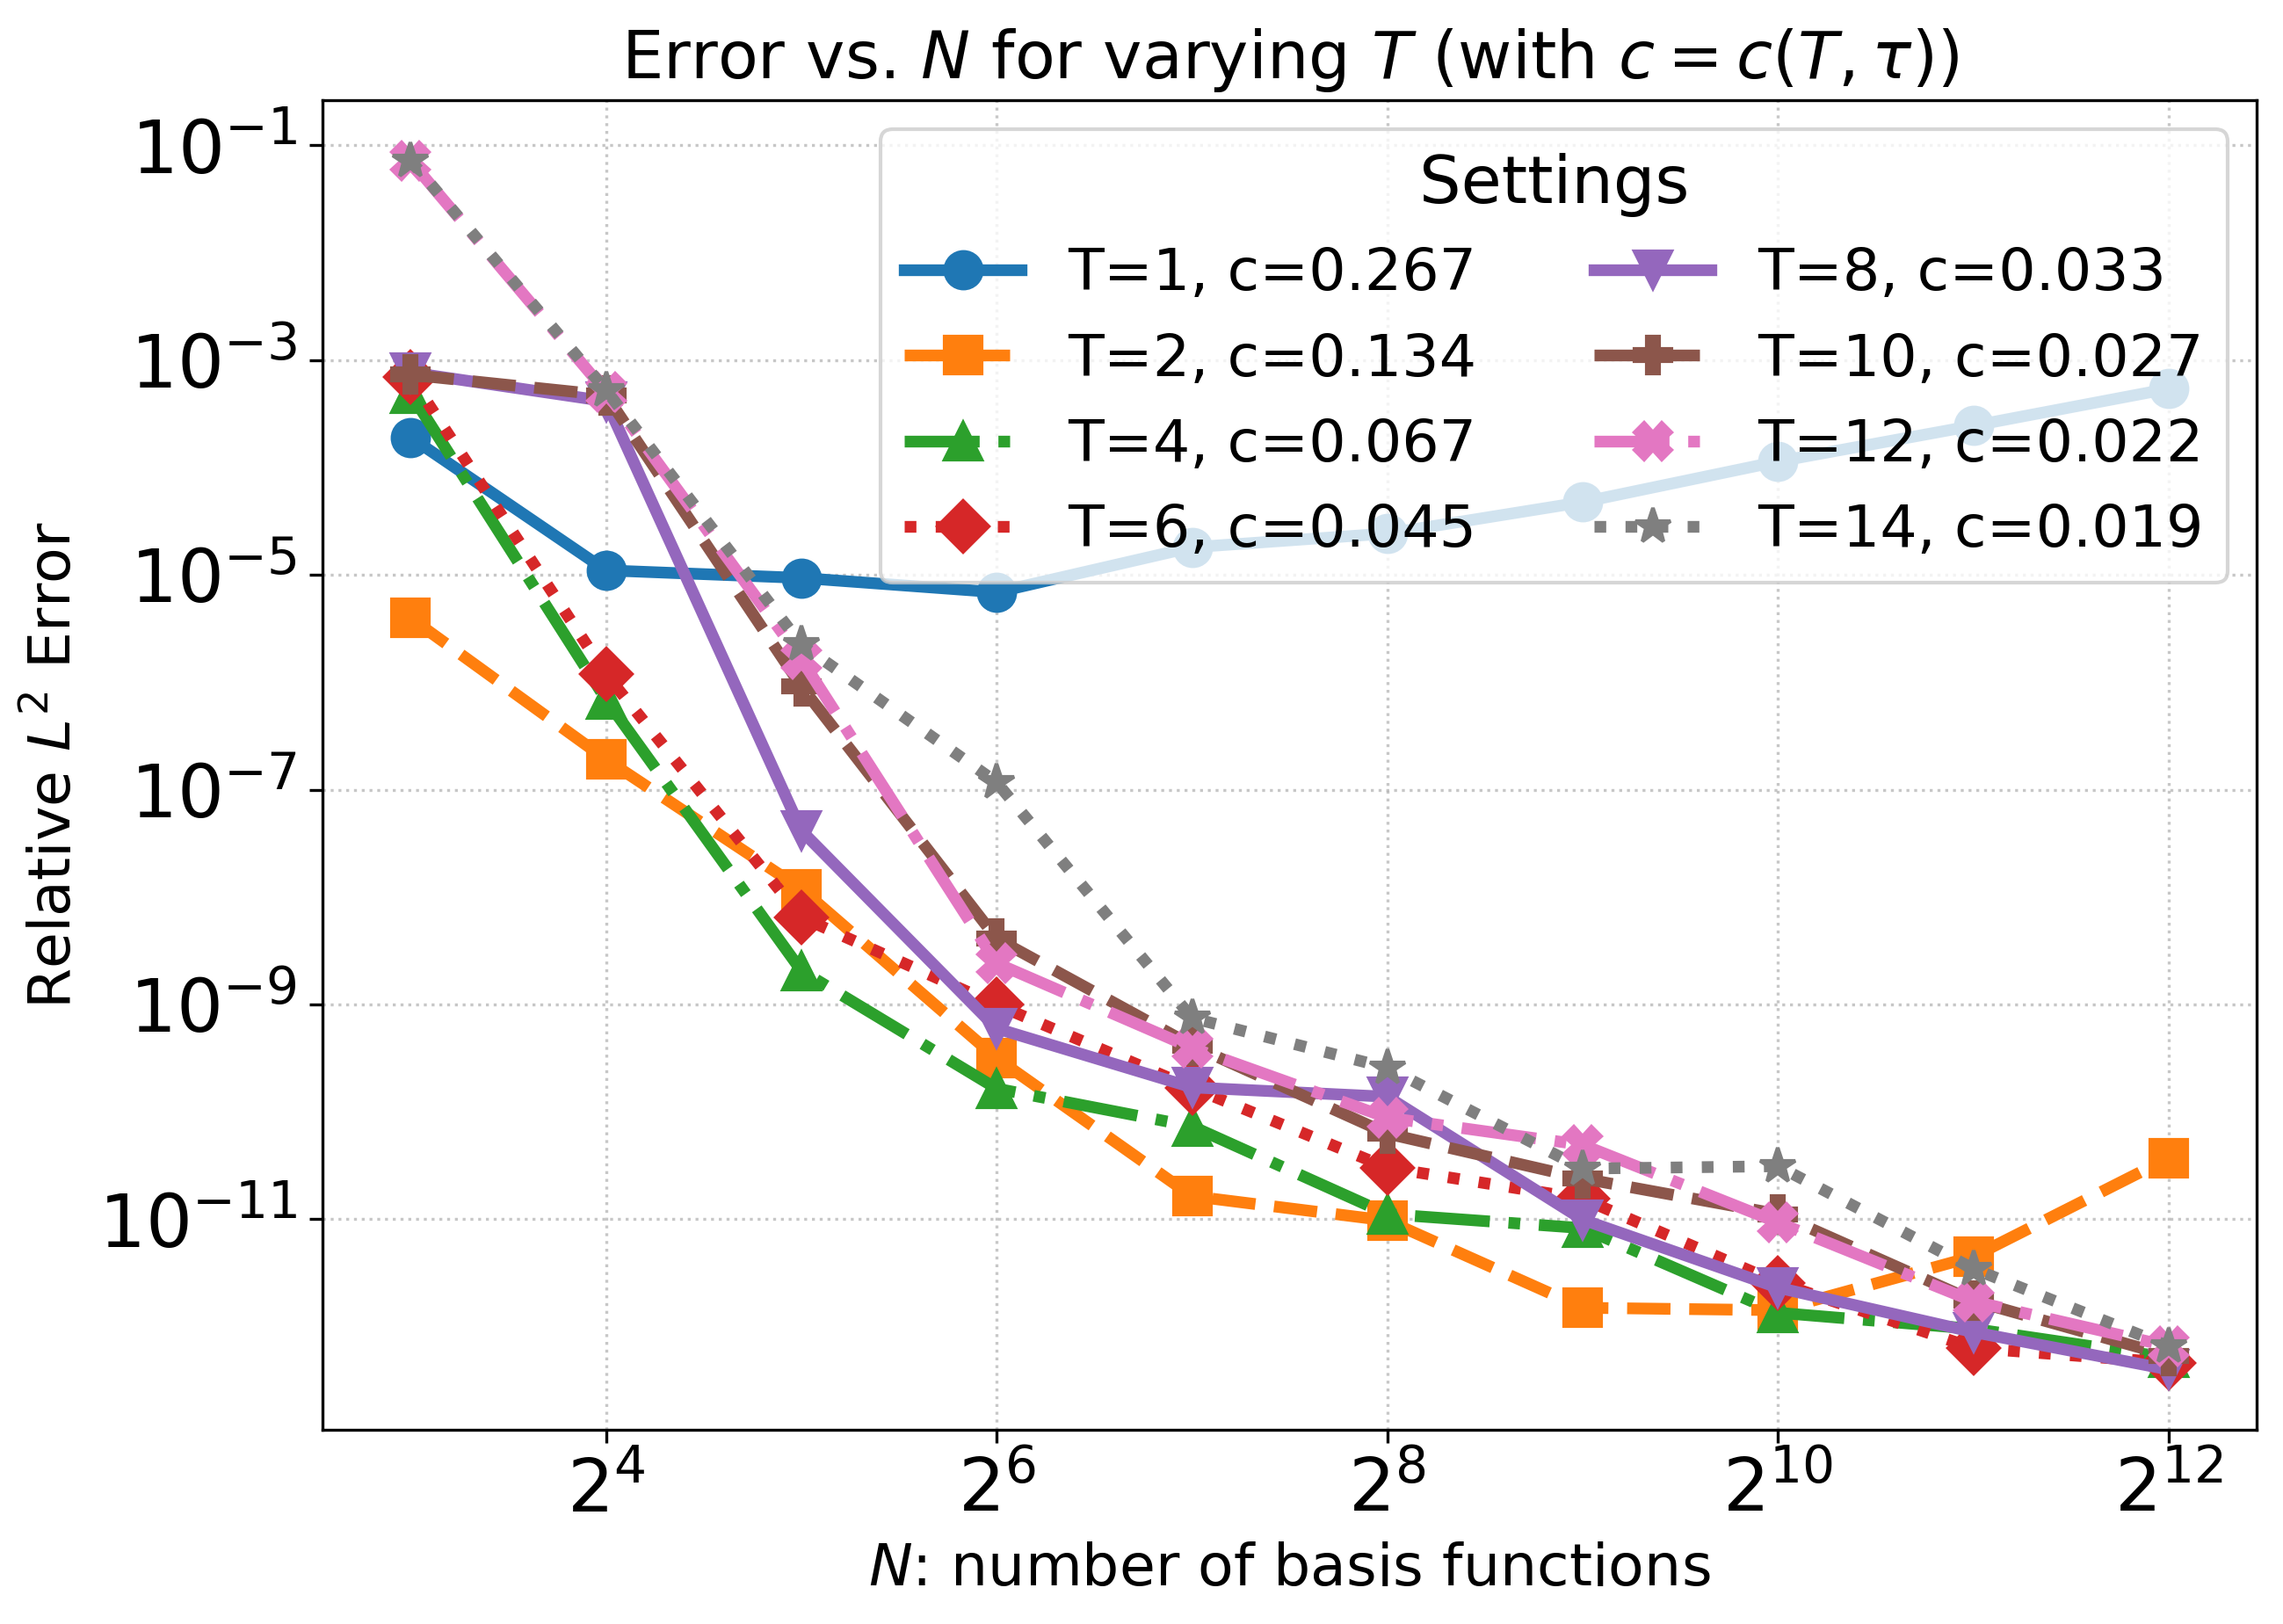

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)
T_values = np.array([1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0], dtype=float)   # trim if you want fewer lines
tau = 1e-15

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: compute c(T) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by (T, c) -> arrays
E = {}        # (T, c) -> array of rel L2 error vs N
Times = {}    # (T, c) -> array of elapsed times vs N

# Precompute c values aligned with T_values
c_values = np.array([c_from_T(T_val, tau) for T_val in T_values], dtype=float)

# Optional: print a quick table of T and c
print("T and c values used:")
for T_val, c_val in zip(T_values, c_values):
    print(f"  T={T_val:>3.1f}  c={c_val:.6e}")

for (T_val, c_val) in zip(T_values, c_values):
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_val, c=c_val)
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    key = (float(T_val), float(c_val))
    E[key] = np.asarray(errs, dtype=float)
    Times[key] = np.asarray(times, dtype=float)

# =======================
# Optional sanity checks (overlay detection across different T,c)
# =======================
if len(T_values) >= 2:
    # Compare to the first pair
    base_key = (float(T_values[0]), float(c_values[0]))
    base_E = E[base_key]
    for i in range(1, len(T_values)):
        other_key = (float(T_values[i]), float(c_values[i]))
        if np.allclose(base_E, E[other_key], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for T={base_key[0]:g}, c={base_key[1]:.3e} "
                  f"and T={other_key[0]:g}, c={other_key[1]:.3f} are numerically identical.")

# =======================
# Plot E(N) vs N for each (T, c)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)
# Sort by T for a consistent legend order
for (T_val, c_val) in sorted(E.keys(), key=lambda t: t[0]):
    y = E[(T_val, c_val)]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=3.2,
        markersize=10,
        label=f"T={T_val:g}, c={c_val:.3f}"
    )

# If you prefer log-x since N doubles, uncomment:
# plt.xscale('log', base=2)

plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(r"Error vs. $N$ for varying $T$ (with $c=c(T,\tau)$)", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.xscale('log', base=2)  # since N often doubles
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=legend_fontsize, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig4_poisson.png')
# plt.show()




## We fix T = 2.0, varying c values

Fixed T = 2.0
c values used:
  c=3.000000e-02
  c=5.000000e-02
  c=8.200000e-02
  c=1.200000e-01
  c=2.000000e-01
  c=3.000000e-01
  c=1.636749e-01


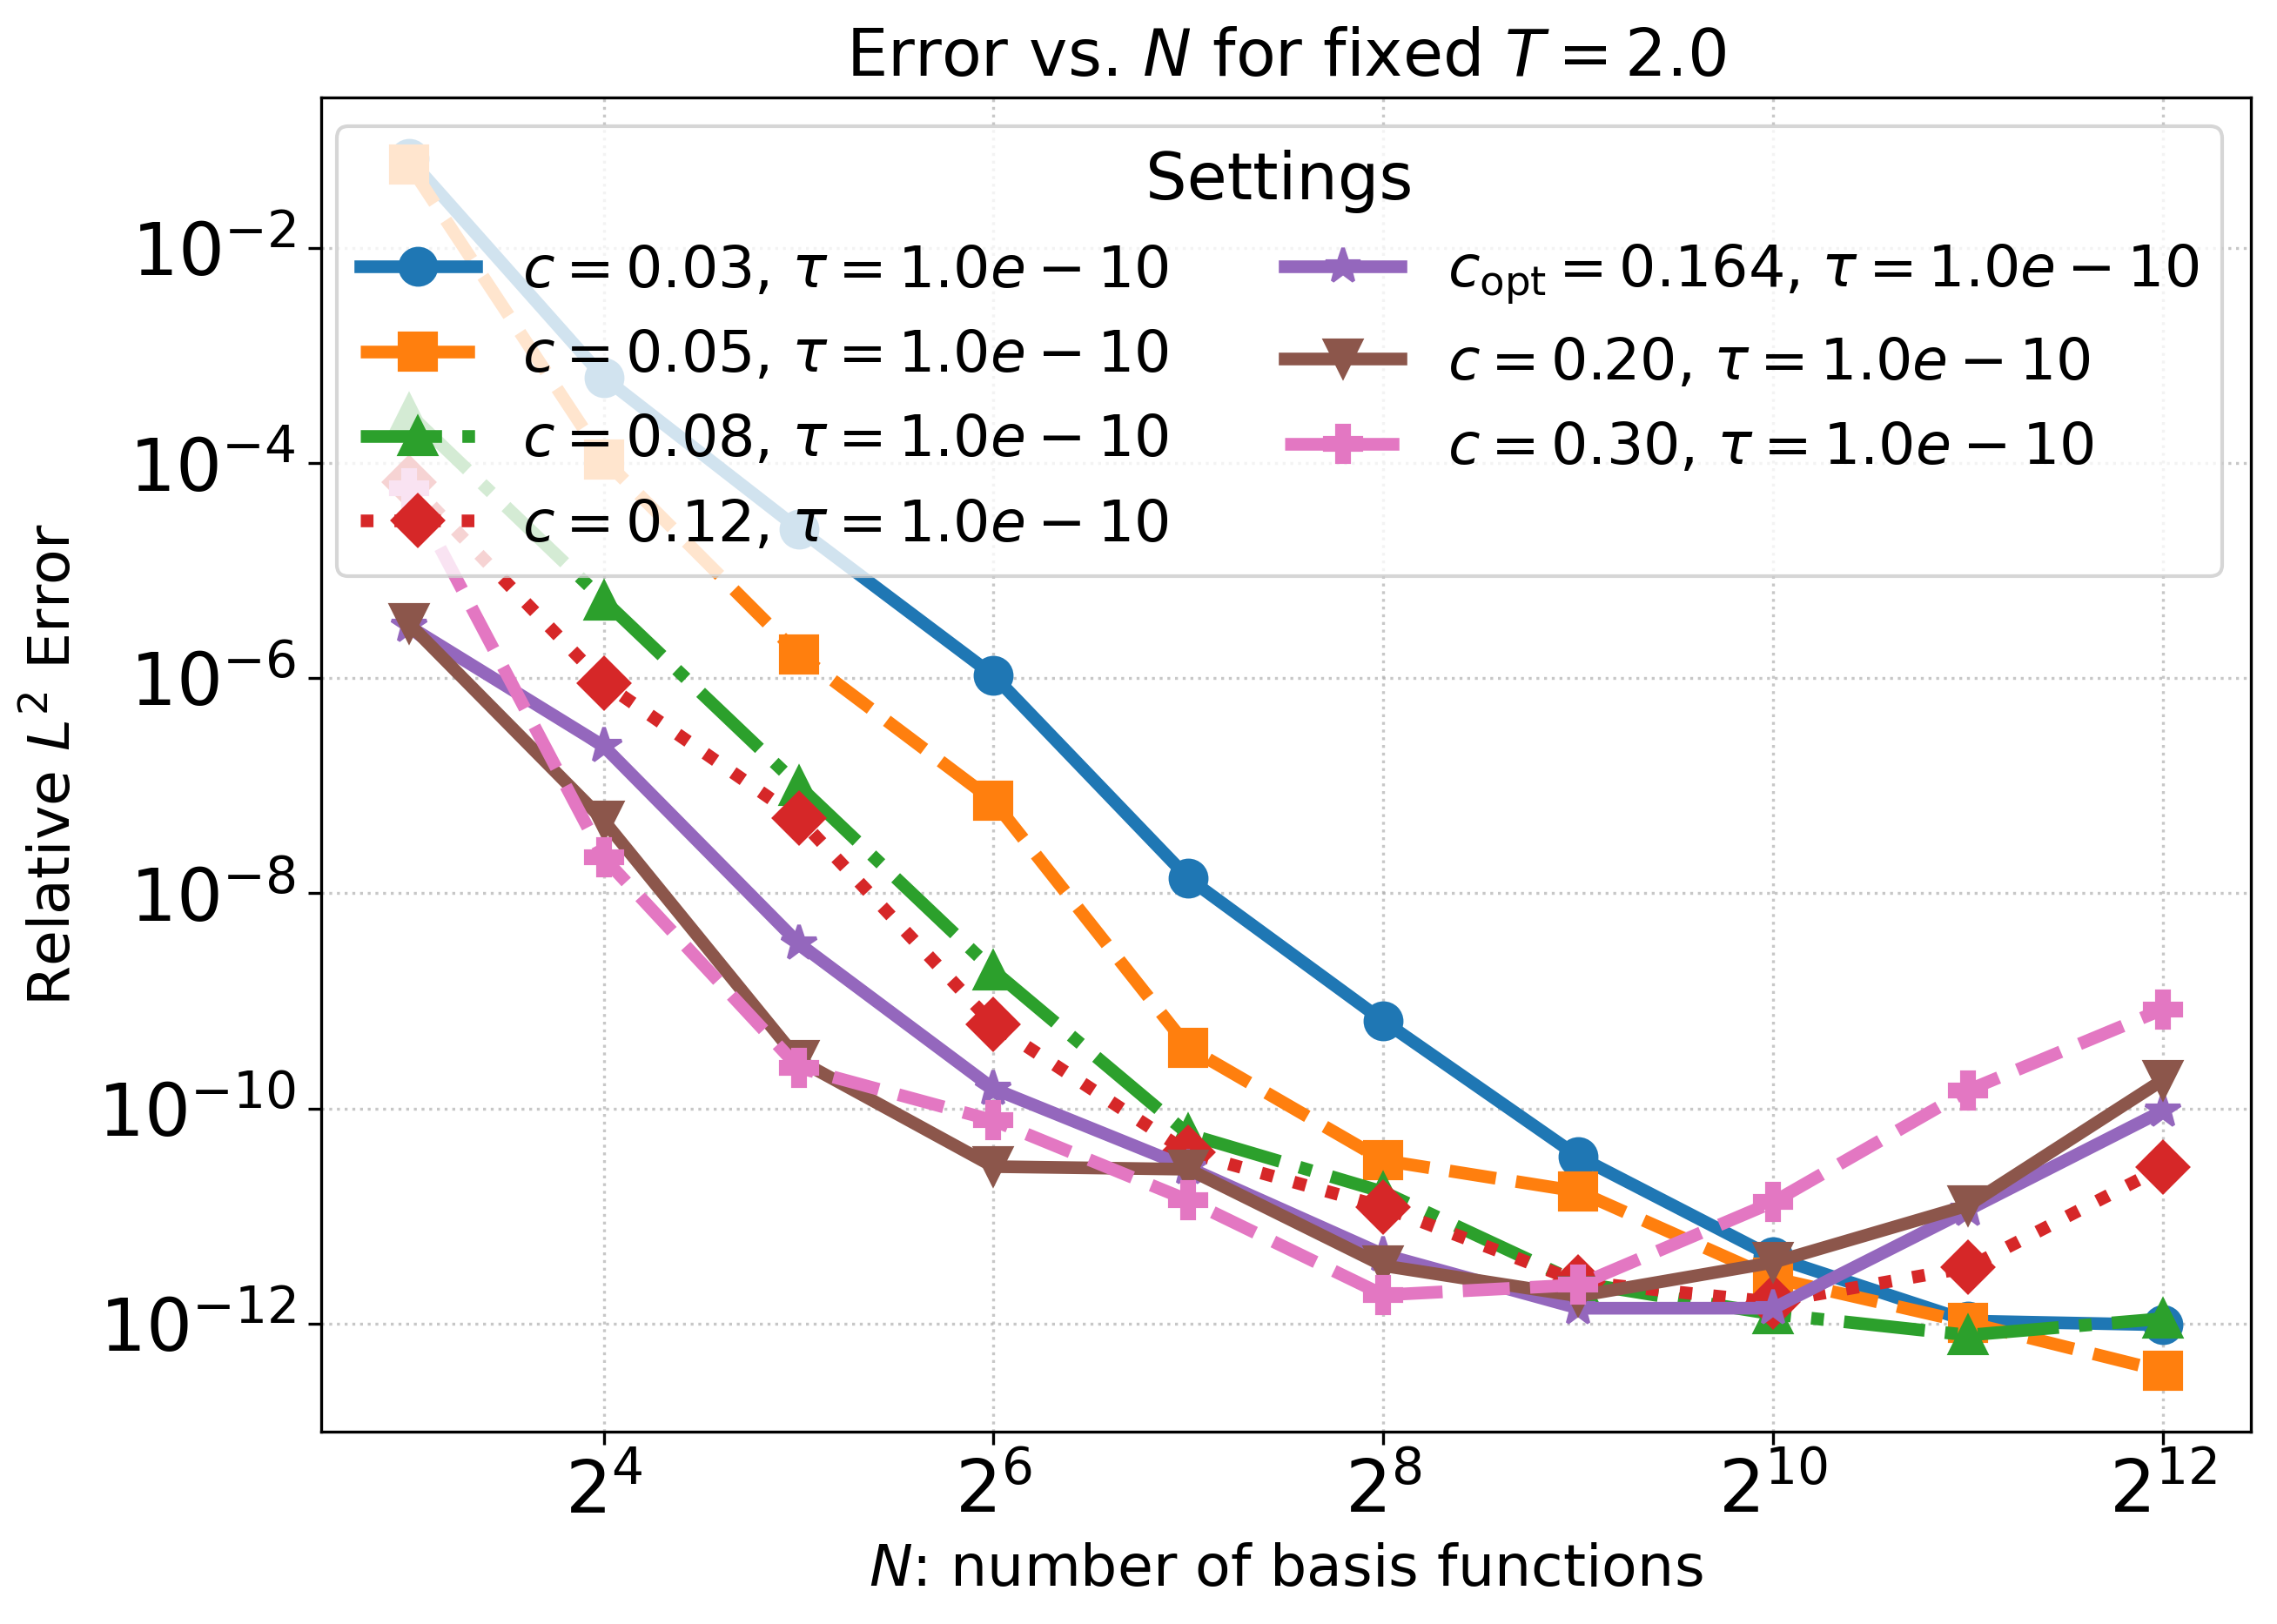

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary c
T_fixed = 2.0
tau = 1e-10

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))



c_optim = c_from_T(T_fixed, tau)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
# Up to 0.3
c_values = np.asarray([0.03, 0.05, 0.082, 0.12, 0.20, 0.30, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N
Times = {}    # c -> array of elapsed times vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(c_val)] = np.asarray(errs, dtype=float)
    Times[float(c_val)] = np.asarray(times, dtype=float)

# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.1e} and c={c_val:.2f} are numerically identical.")

# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
# plt.xscale('log', base=2)

plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.xscale('log', base=2)  # since N often doubles
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig5_poisson.png')
# plt.show()


Fixed T = 4.0
c values used:
  c=3.000000e-02
  c=5.000000e-02
  c=8.200000e-02
  c=1.200000e-01
  c=2.000000e-01
  c=3.000000e-01
  c=8.183744e-02


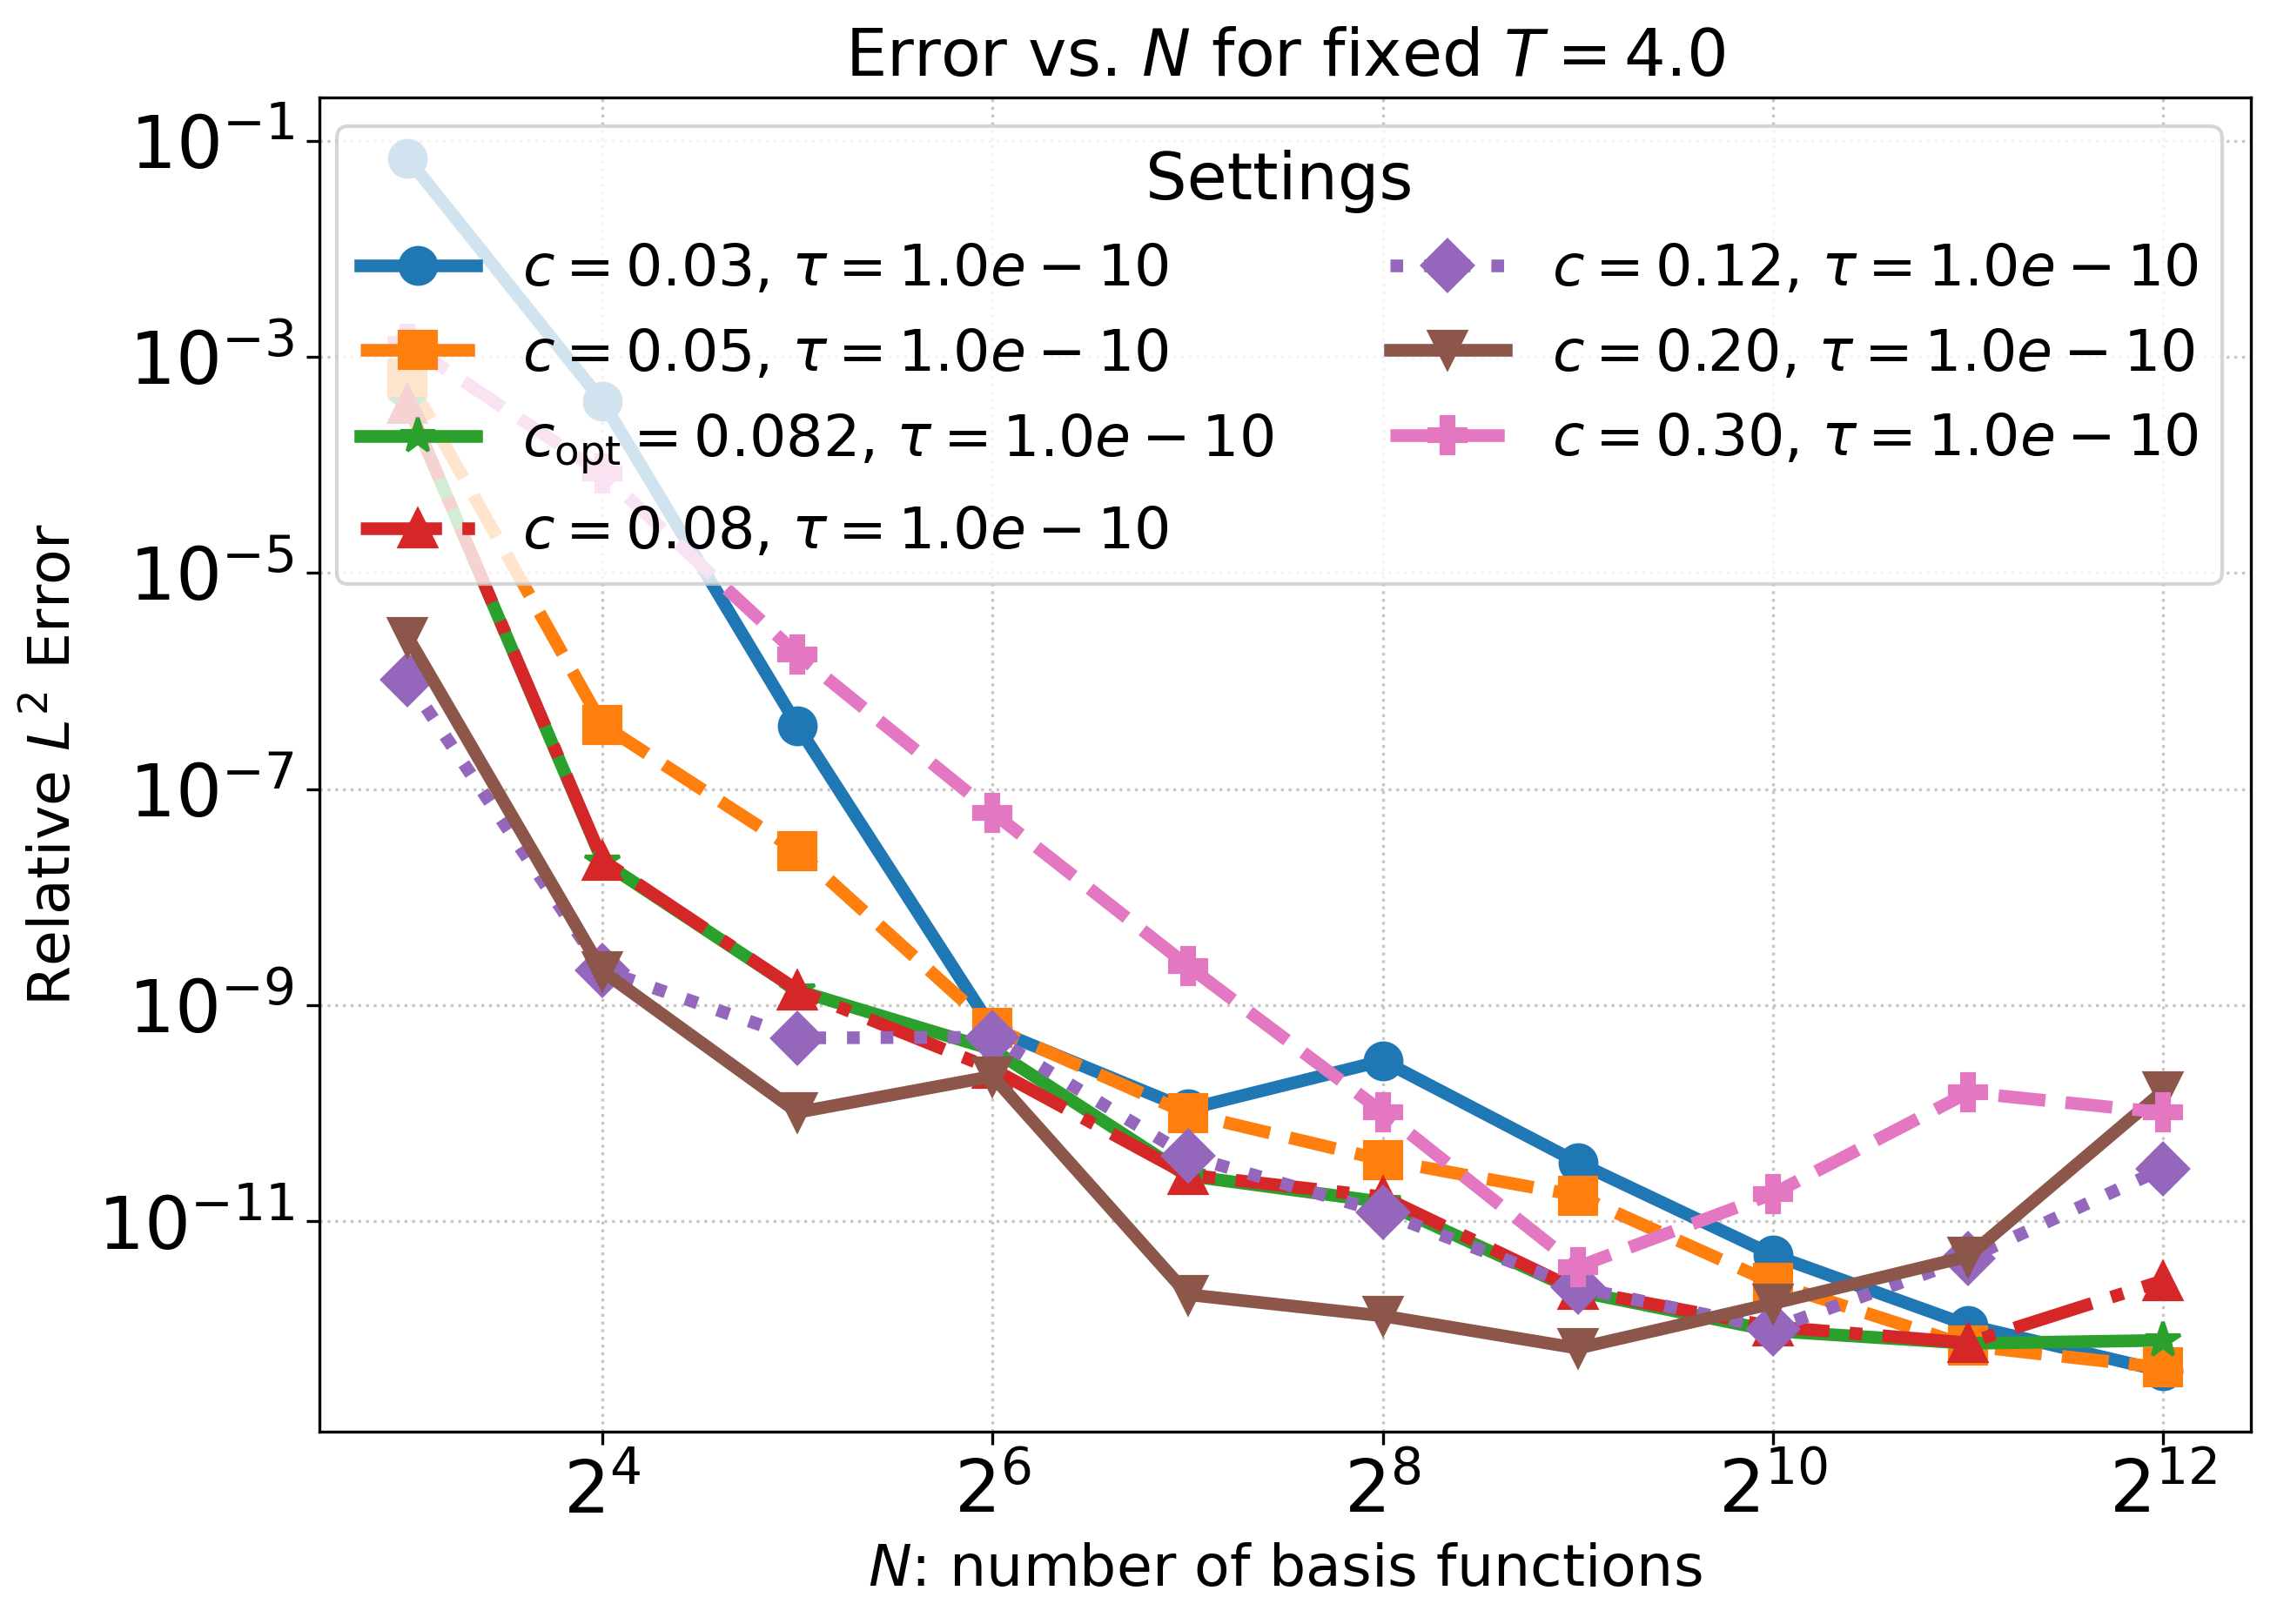

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary c
T_fixed = 4.0
tau = 1e-10

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))



c_optim = c_from_T(T_fixed, tau)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.03, 0.05, 0.082, 0.12, 0.20, 0.30, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N
Times = {}    # c -> array of elapsed times vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(c_val)] = np.asarray(errs, dtype=float)
    Times[float(c_val)] = np.asarray(times, dtype=float)

# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.3e} and c={c_val:.3e} are numerically identical.")

# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
plt.xscale('log', base=2)  # since N often doubles
plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig6_poisson.png')
# plt.show()


Fixed T = 6.0
c values used:
  c=3.000000e-02
  c=5.000000e-02
  c=8.200000e-02
  c=1.200000e-01
  c=2.000000e-01
  c=3.000000e-01
  c=5.455829e-02


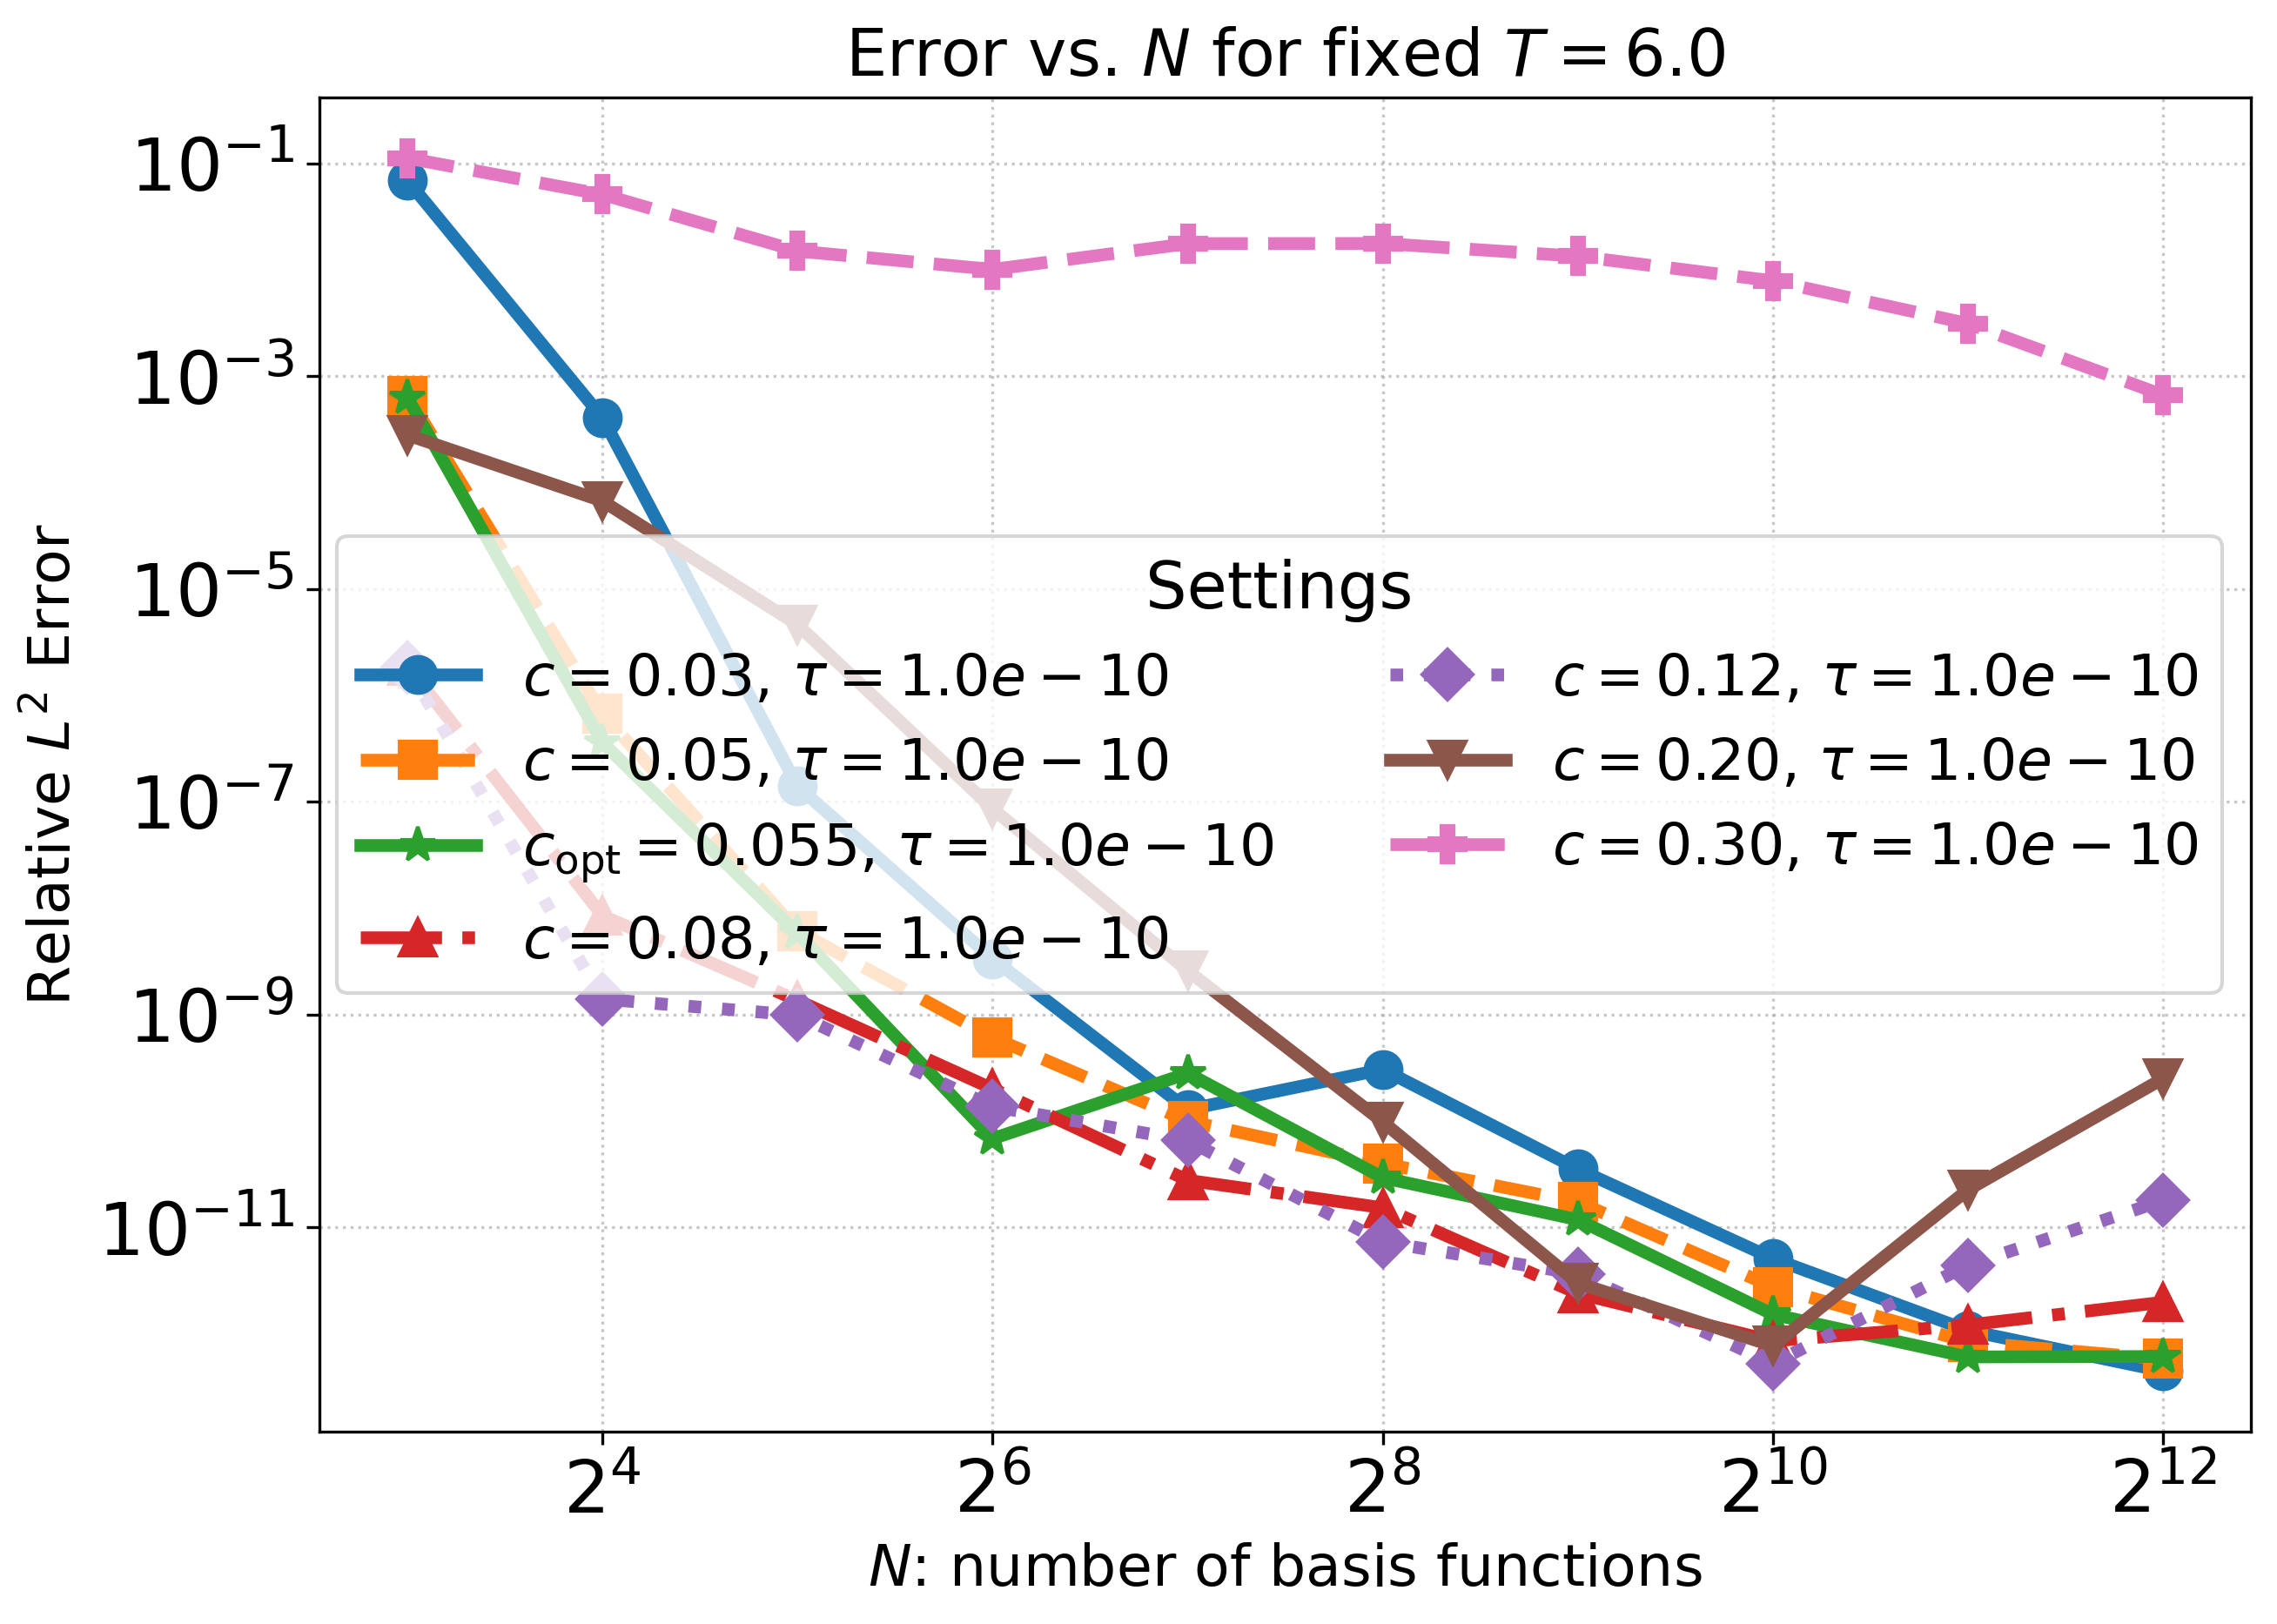

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary c
T_fixed = 6.0
tau = 1e-10

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.03, 0.05, 0.082, 0.12, 0.20, 0.30, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N
Times = {}    # c -> array of elapsed times vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(c_val)] = np.asarray(errs, dtype=float)
    Times[float(c_val)] = np.asarray(times, dtype=float)

# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.3e} and c={c_val:.3e} are numerically identical.")

# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
# plt.xscale('log', base=2)
plt.xscale('log', base=2)  # since N often doubles
plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig7_poisson.png')
# plt.show()


Fixed T = 8.0
c values used:
  c=3.000000e-02
  c=5.000000e-02
  c=8.200000e-02
  c=1.200000e-01
  c=2.000000e-01
  c=3.000000e-01
  c=4.091872e-02


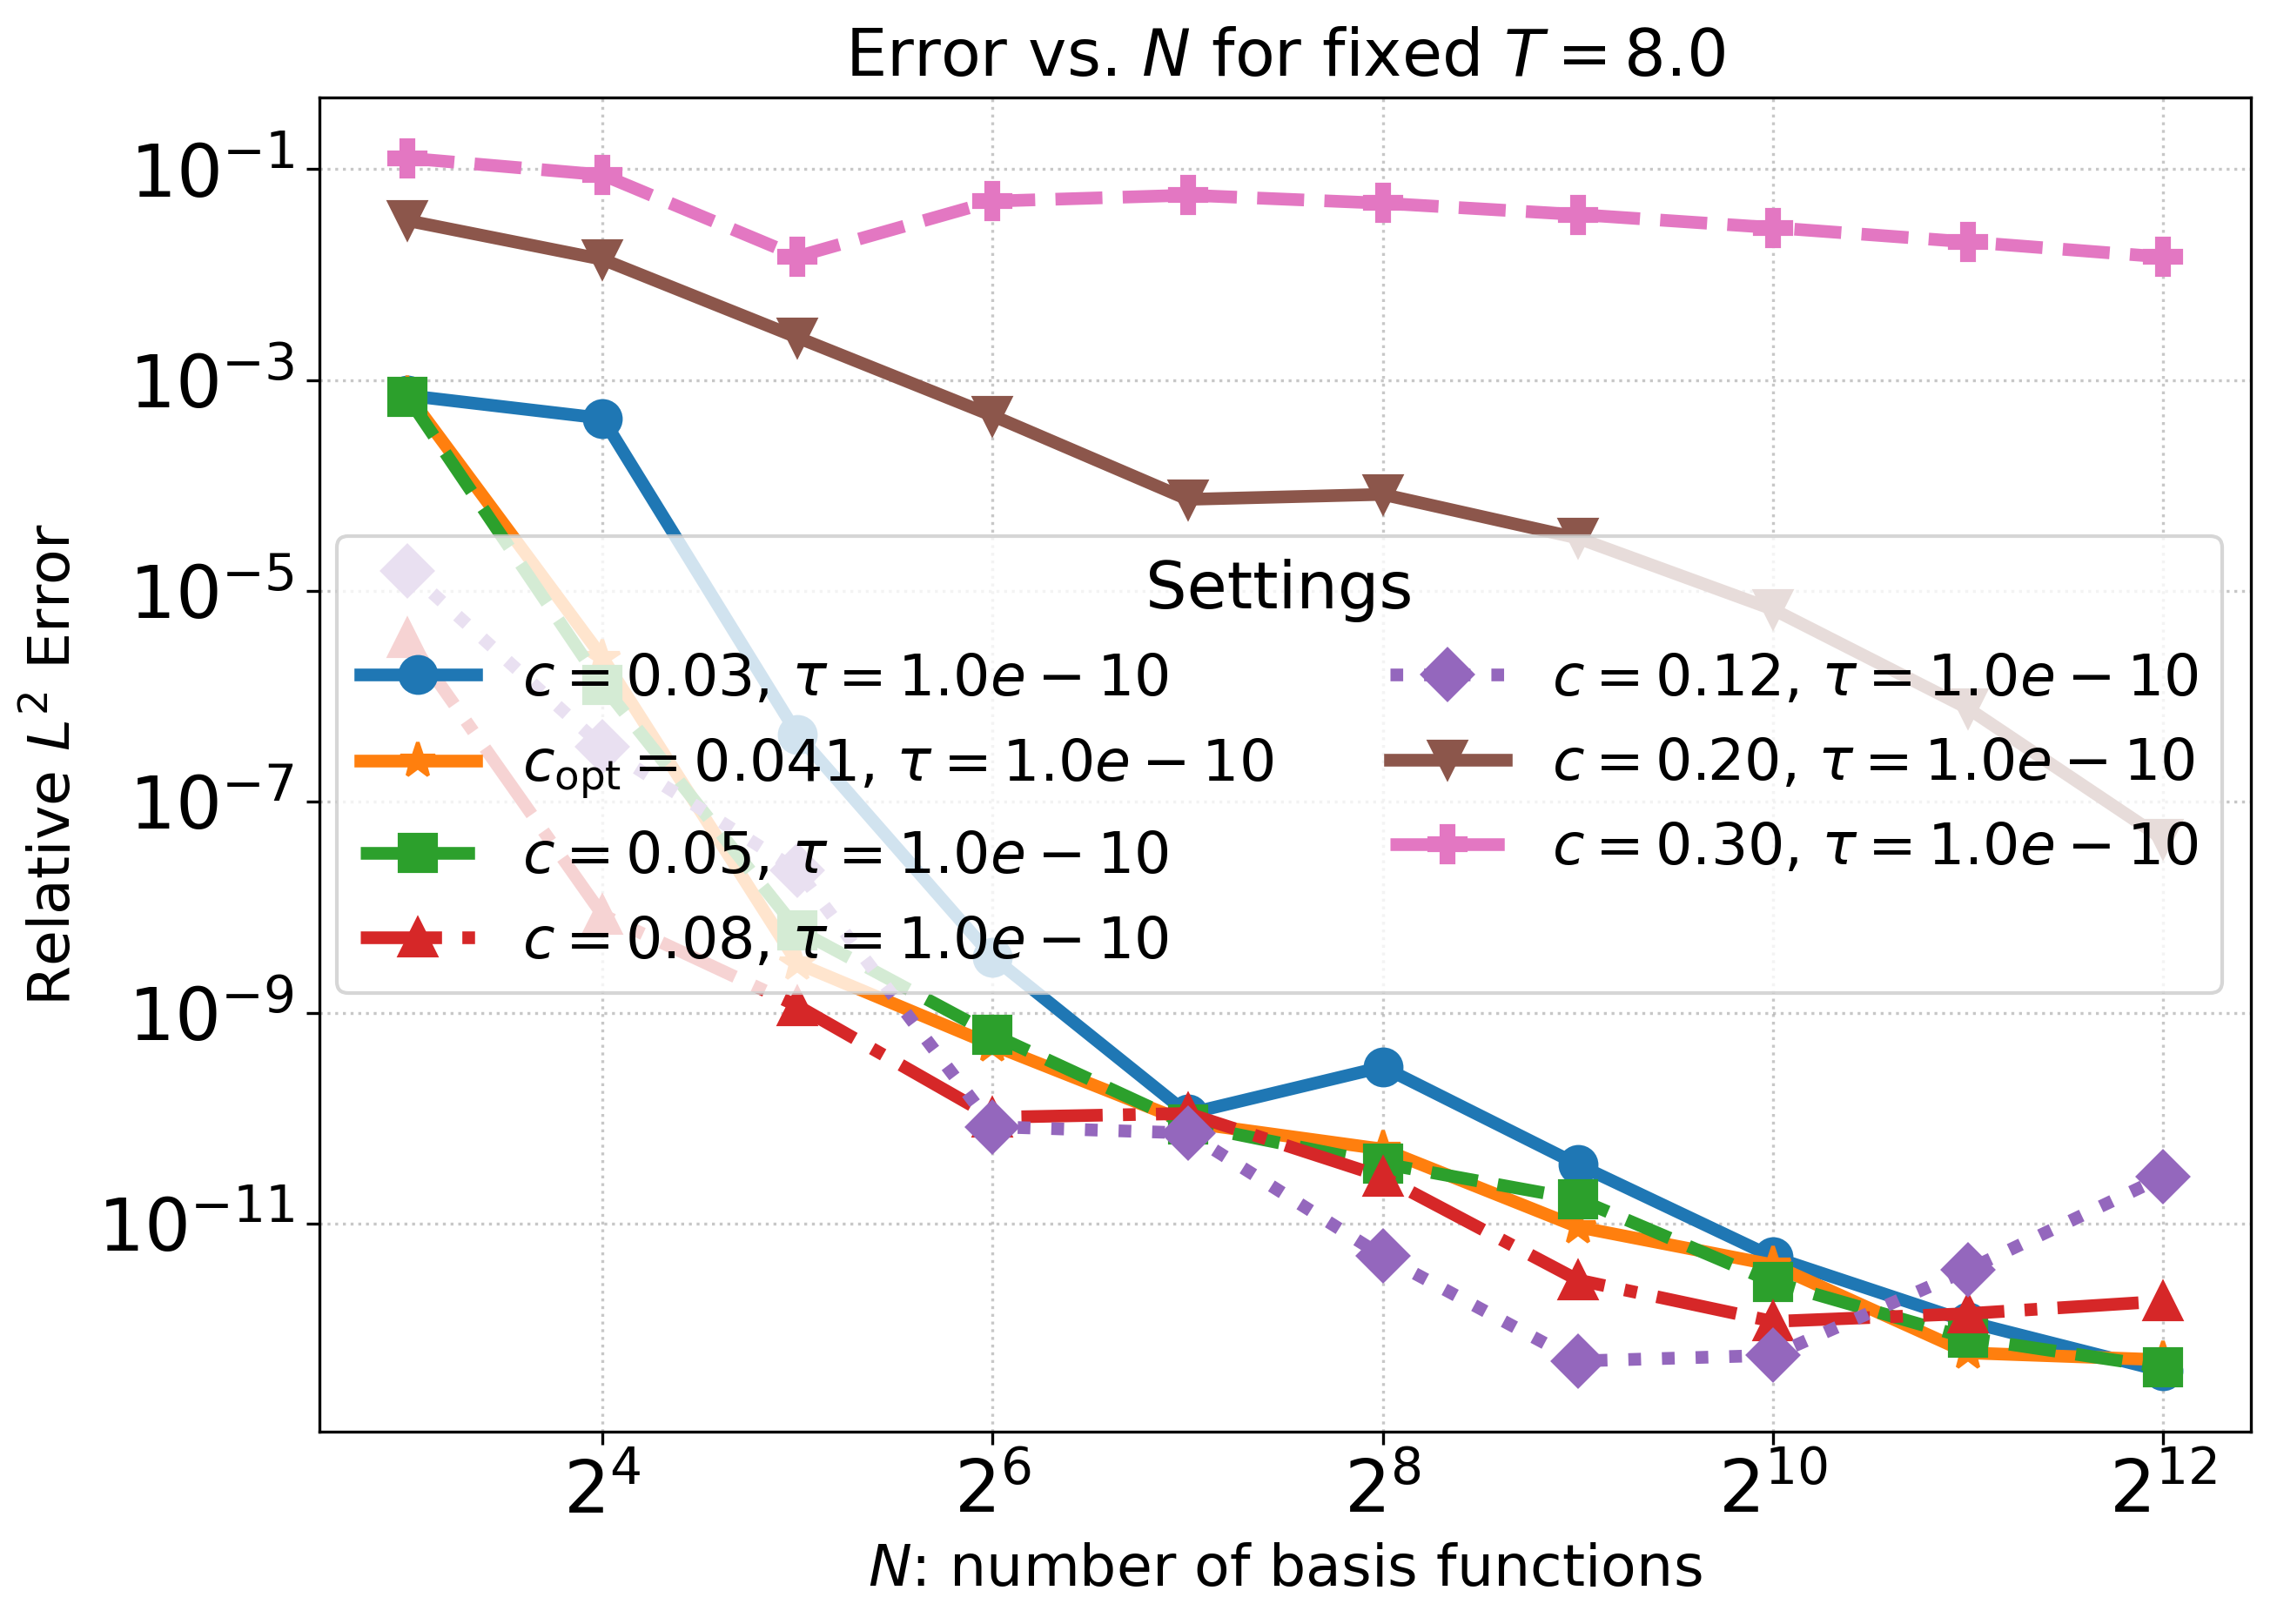

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary c
T_fixed = 8.0
tau = 1e-10

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: compute c(T) via your formula (optional utility)
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

c_optim = c_from_T(T_fixed, tau)
# Choose explicit c sweep
# You can also generate around the formula value:
# c0 = c_from_T(T_fixed, tau); c_values = c0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
#c_values = np.asarray([0.1, 0.3, 0.5, 0.7, 0.9, 1.0], dtype=float)
c_values = np.asarray([0.03, 0.05, 0.082, 0.12, 0.20, 0.30, c_optim], dtype = float)
# =======================
# Run experiments
# =======================
# Store by c -> arrays
E = {}        # c -> array of rel L2 error vs N
Times = {}    # c -> array of elapsed times vs N

# Print a quick table of T and c
print(f"Fixed T = {T_fixed}")
print("c values used:")
for c_val in c_values:
    print(f"  c={c_val:.6e}")

for c_val in c_values:
    errs = []
    times = []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(c_val)] = np.asarray(errs, dtype=float)
    Times[float(c_val)] = np.asarray(times, dtype=float)

# =======================
# Optional sanity check (overlay detection across different c)
# =======================
if len(c_values) >= 2:
    base_c = float(c_values[0])
    base_E = E[base_c]
    for c_val in c_values[1:]:
        c_val = float(c_val)
        if np.allclose(base_E, E[c_val], rtol=1e-10, atol=1e-12, equal_nan=True):
            print(f"Note: E(N) for c={base_c:.3e} and c={c_val:.3e} are numerically identical.")

# =======================
# Plot E(N) vs N for each c (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

# Sort legend by c for consistency
for c_val in sorted(E.keys()):
    y = E[c_val]
    # Guard against non-positive values on log scale
    y_plot = np.where(y > 0, y, np.nan)
    is_opt = abs(c_val - c_optim)<= 1e-15
    plt.plot(
        N_values, y_plot,
        marker=('*' if is_opt else next(marker_cycle)),
        linestyle=('-' if is_opt else next(linestyle_cycle)),
        linewidth=3.5,
        markersize=10,
        label = (rf"$c_\mathrm{{opt}} = {c_optim:.3f}$, $\tau = {tau:.1e}$" 
                 if is_opt else rf"$c={c_val:.2f}$, $\tau={tau:.1e}$")
        #label=fr"$c={c_val:.2f}$, $\tau={tau:.1e}$"
    )

# If you prefer log-x since N doubles, uncomment:
# plt.xscale('log', base=2)
plt.xscale('log', base=2)  # since N often doubles
plt.yscale('log')  # typical for errors
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ for fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig8_poisson.png')
# plt.show()


## Experiment for fixed $T$, variation of $\tau$ threshold and $c$

Fixed T = 2.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


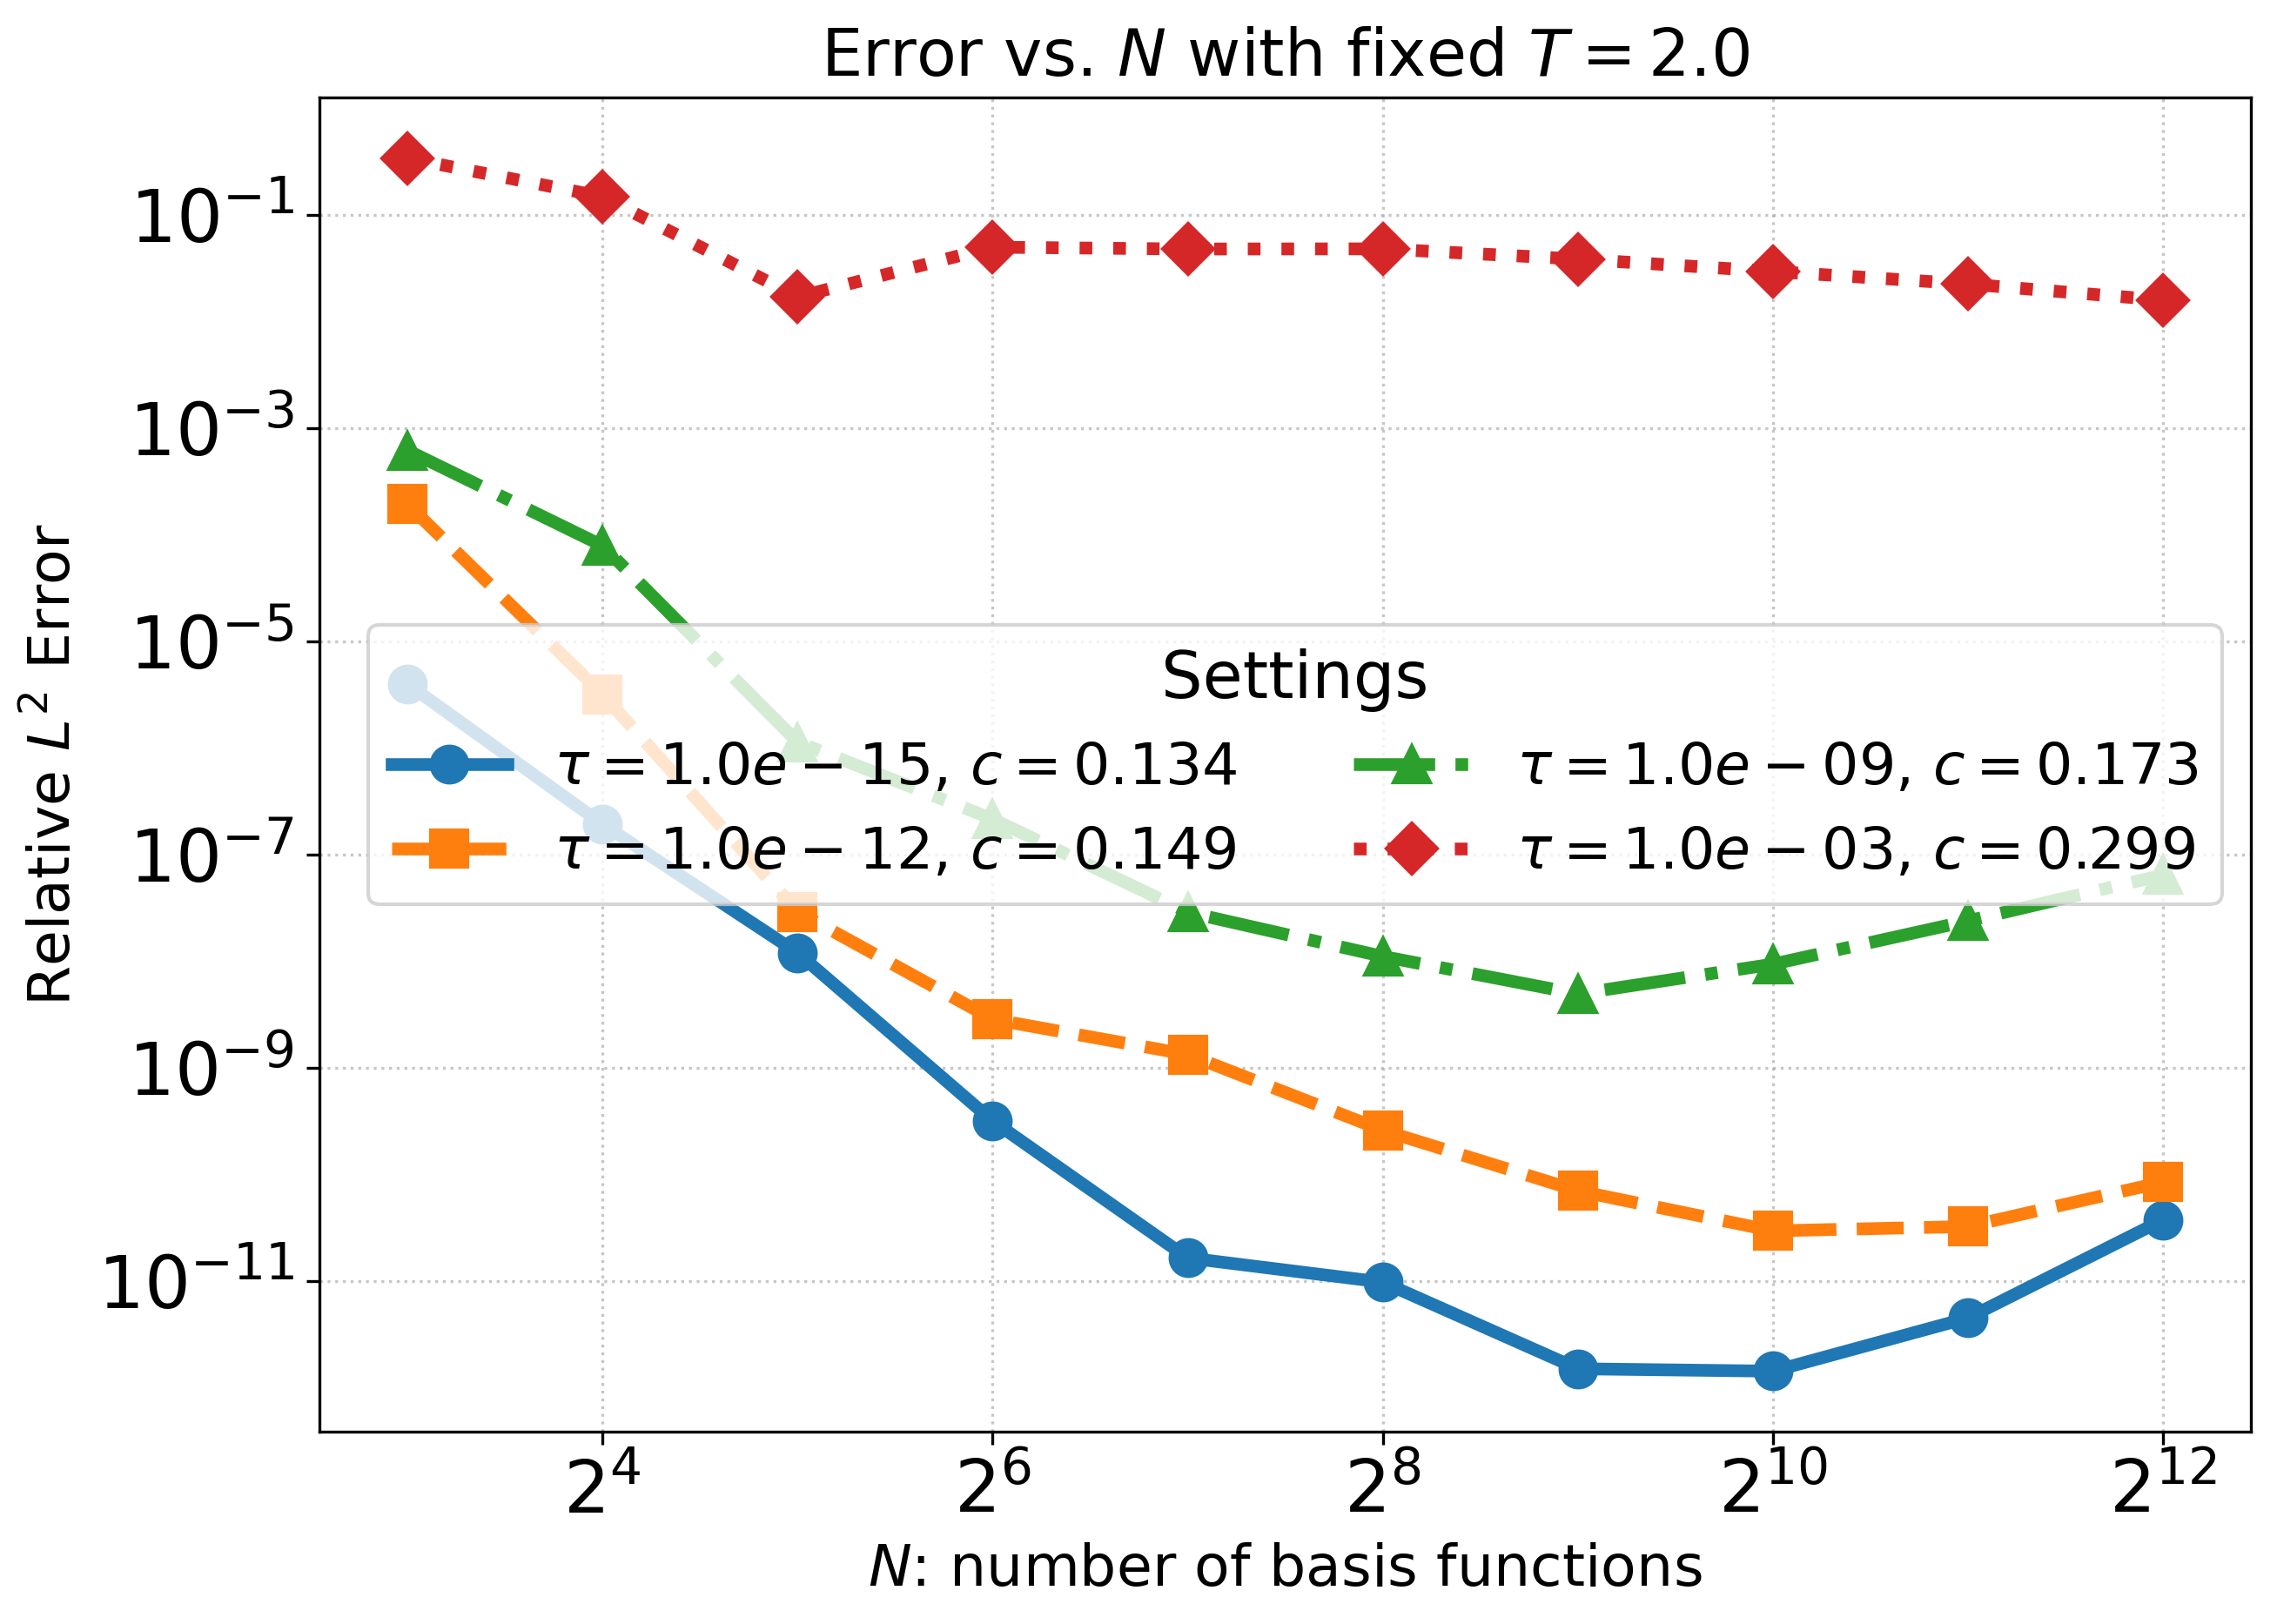

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary tau
T_fixed = 2.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Choose how to handle c:
C_FIXED = 0.5  # <-- keep a constant c for all tau (default)
USE_c_from_tau = True  # set True to compute c(T, tau) below

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Times = {}    # tau -> array of elapsed times vs N
Cs_used = {}  # tau -> c actually used (for logging)

print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau) if USE_c_from_tau else C_FIXED
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val), tau=float(tau))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)
    Cs_used[float(tau)] = float(c_val)

# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=3.5,
        markersize=10,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig9_poisson.png')
# plt.show()


Fixed T = 4.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


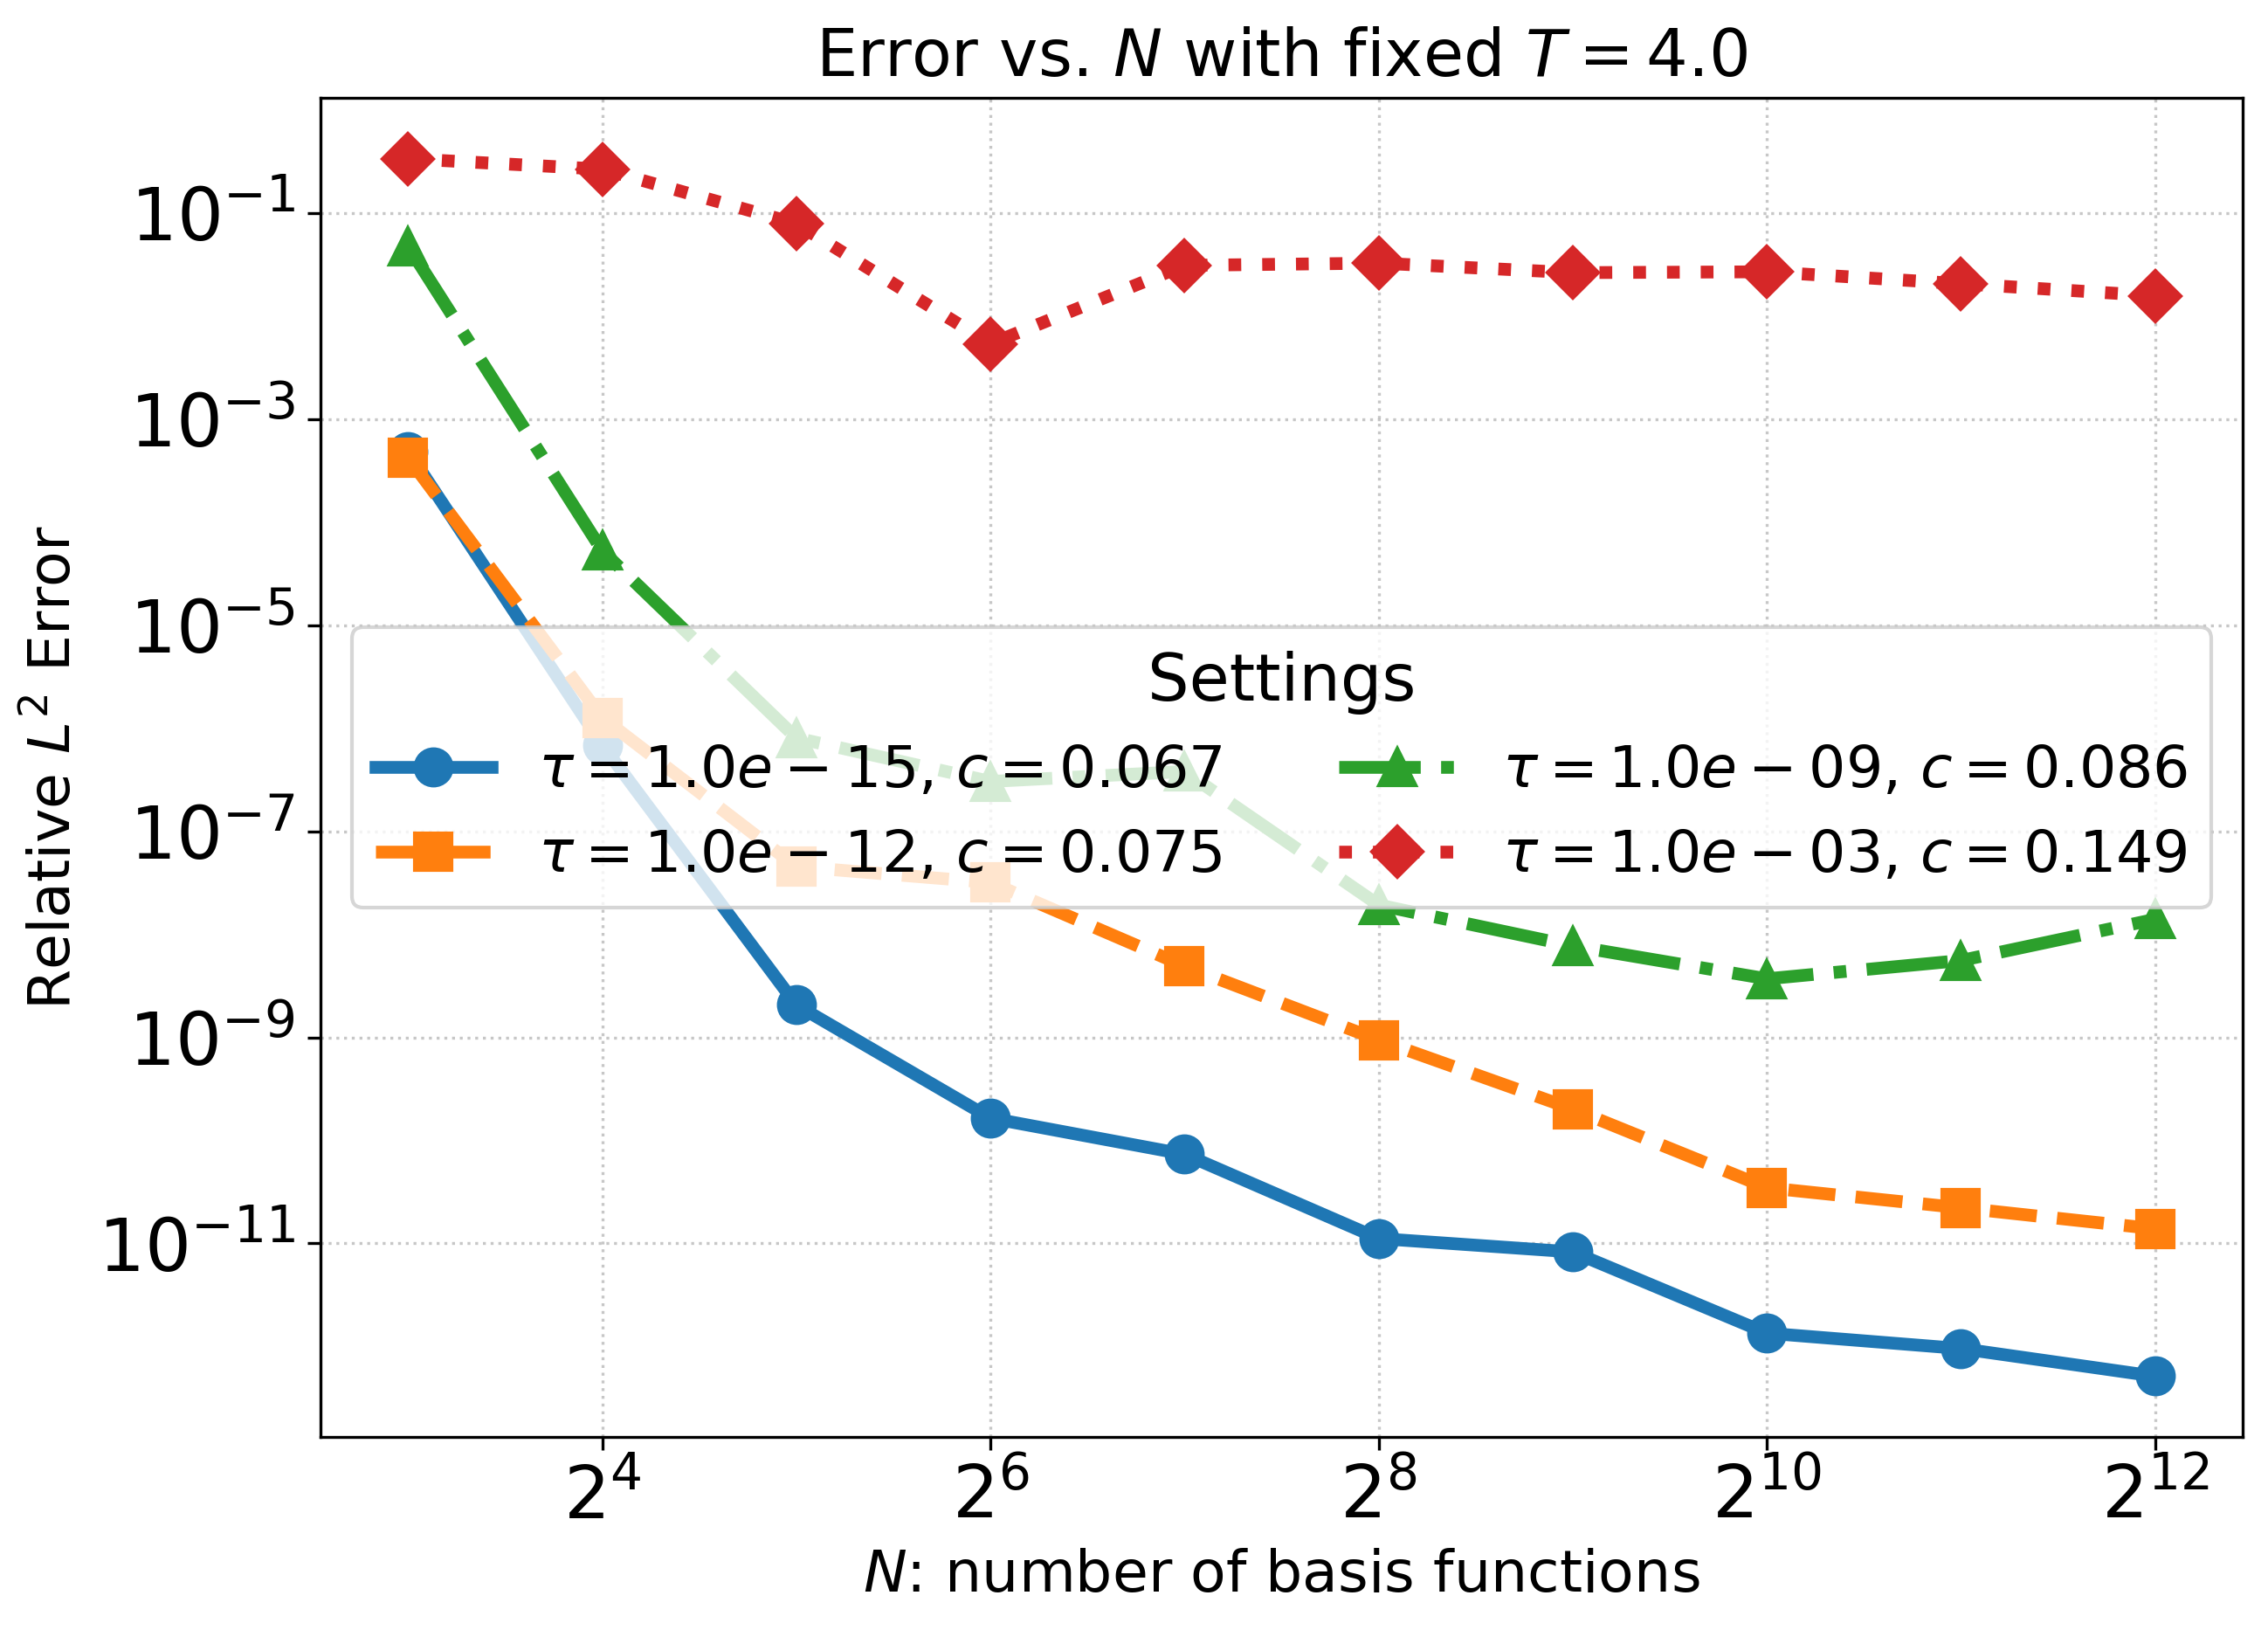

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary tau
T_fixed = 4.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Choose how to handle c:
C_FIXED = 0.5  # <-- keep a constant c for all tau (default)
USE_c_from_tau = True  # set True to compute c(T, tau) below

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Times = {}    # tau -> array of elapsed times vs N
Cs_used = {}  # tau -> c actually used (for logging)

print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau) if USE_c_from_tau else C_FIXED
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val), tau=float(tau))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)
    Cs_used[float(tau)] = float(c_val)

# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=3.5,
        markersize=10,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig10_poisson.png')
# plt.show()


Fixed T = 6.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


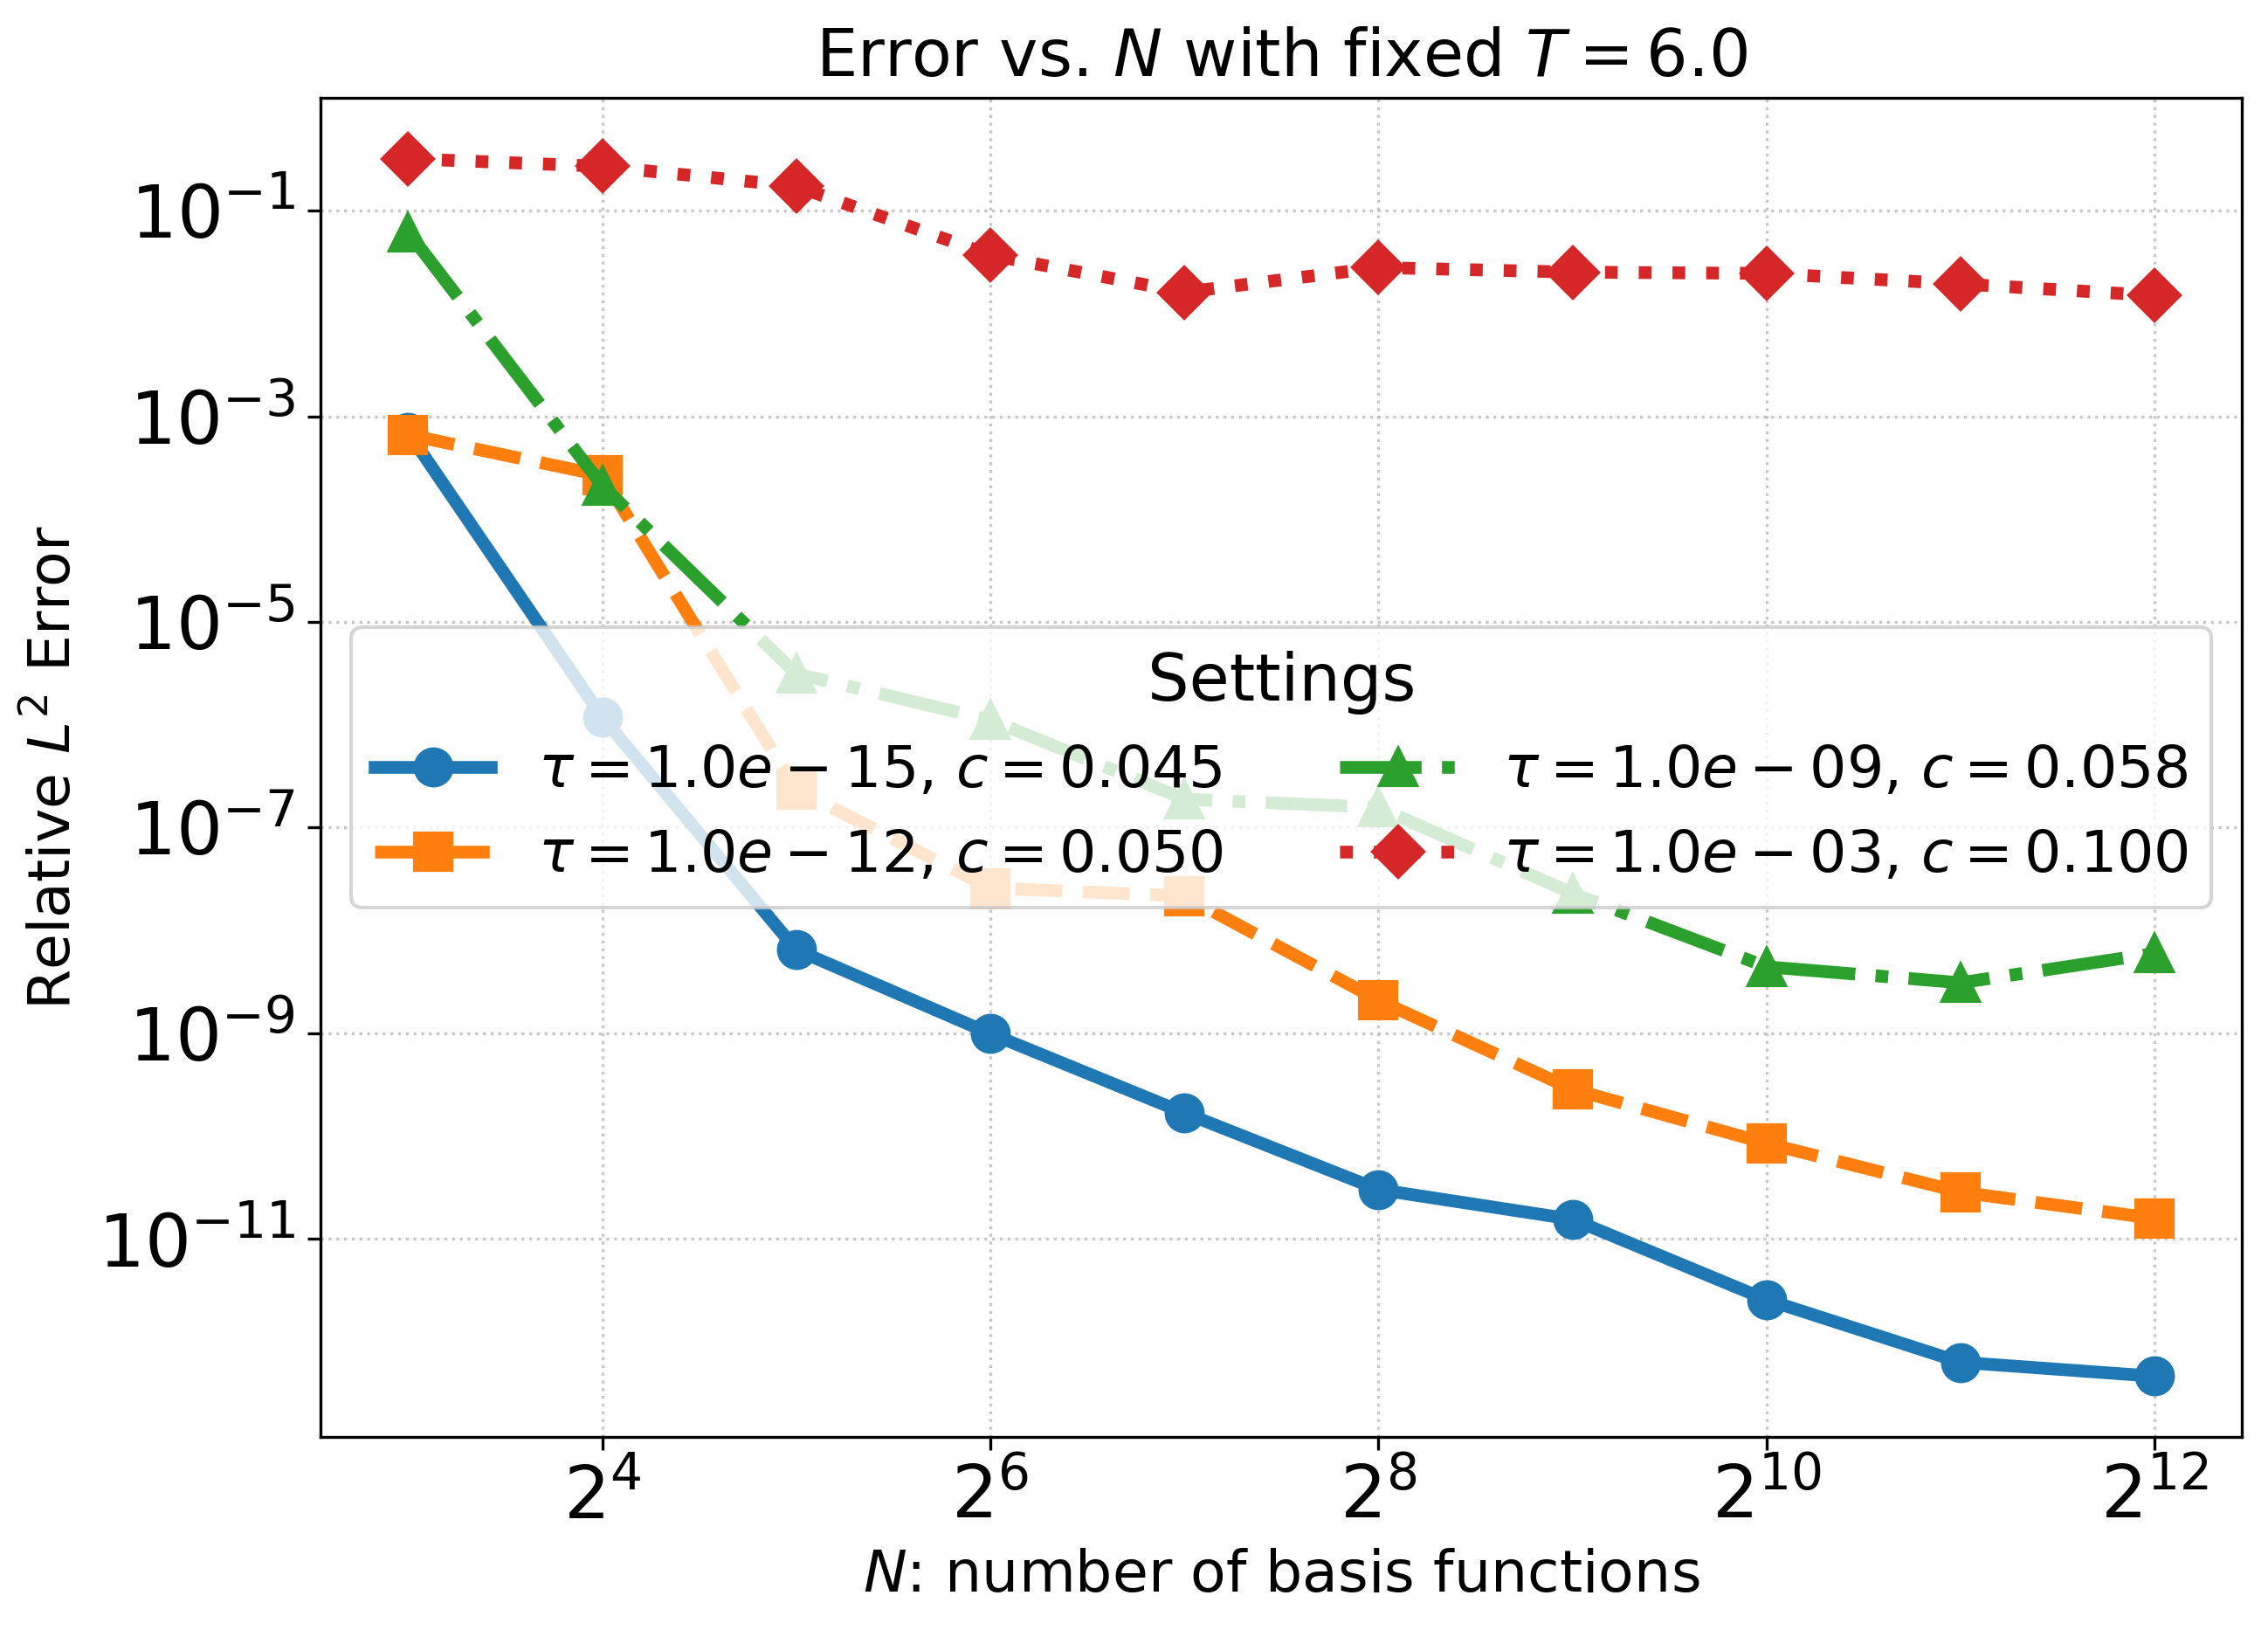

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary tau
T_fixed = 6.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Choose how to handle c:
C_FIXED = 0.5  # <-- keep a constant c for all tau (default)
USE_c_from_tau = True  # set True to compute c(T, tau) below

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Times = {}    # tau -> array of elapsed times vs N
Cs_used = {}  # tau -> c actually used (for logging)

print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau) if USE_c_from_tau else C_FIXED
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val), tau=float(tau))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)
    Cs_used[float(tau)] = float(c_val)

# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=3.5,
        markersize=10,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig11_poisson.png')
# plt.show()


Fixed T = 8.0
tau values used:
  tau=1.000e-03
  tau=1.000e-09
  tau=1.000e-12
  tau=1.000e-15


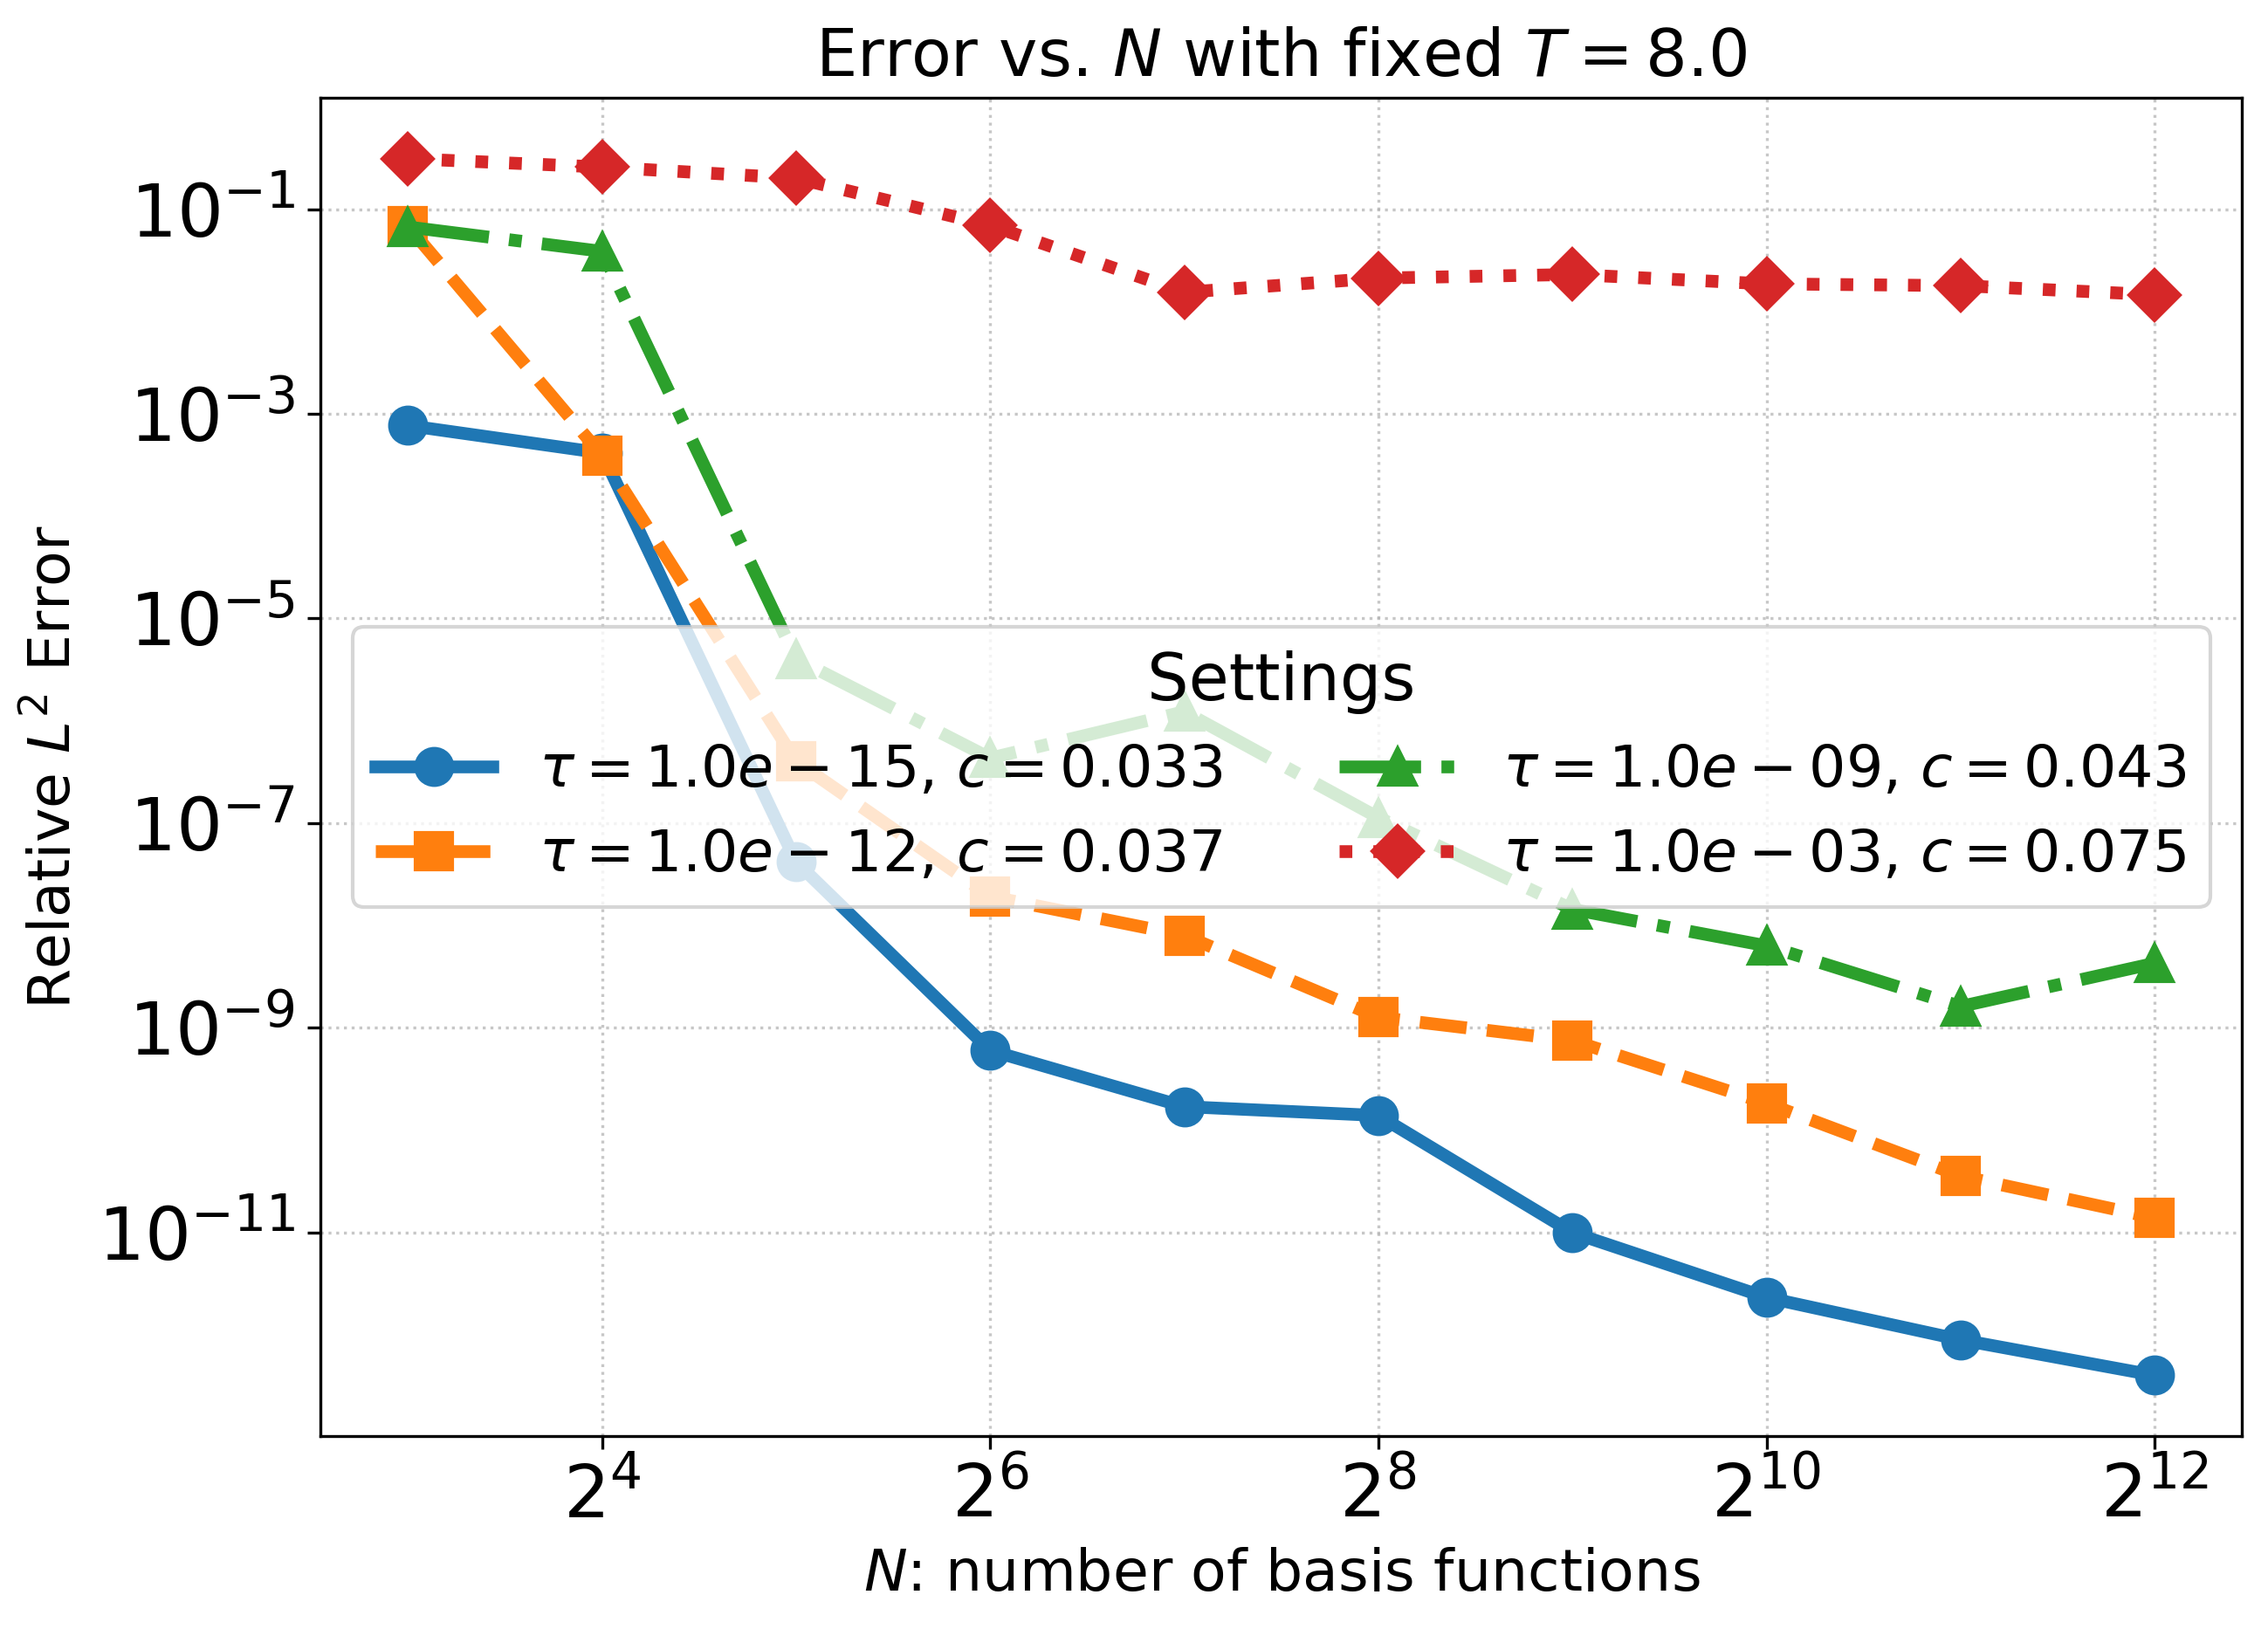

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# =======================
# Config
# =======================
N_values = np.array([8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096], dtype=int)

# Fix T and vary tau
T_fixed = 8.0
tau_values = np.asarray([1e-3, 1e-9, 1e-12, 1e-15], dtype=float)

# Choose how to handle c:
C_FIXED = 0.5  # <-- keep a constant c for all tau (default)
USE_c_from_tau = True  # set True to compute c(T, tau) below

# Domain endpoints (ensure a1 < a2)
a1, a2 = -1.0, -1.5
if a1 > a2:
    a1, a2 = a2, a1

# Helper: c(T, tau) via your formula
def c_from_T(T, tau):
    # c = pi / (T * sqrt(2 * log(1 + tau^{-2})))
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# =======================
# Run experiments
# =======================
# Store by tau -> arrays
E = {}        # tau -> array of rel L2 error vs N
Times = {}    # tau -> array of elapsed times vs N
Cs_used = {}  # tau -> c actually used (for logging)

print(f"Fixed T = {T_fixed}")
print("tau values used:")
for tau in tau_values:
    print(f"  tau={tau:.3e}")

for tau in tau_values:
    c_val = c_from_T(T_fixed, tau) if USE_c_from_tau else C_FIXED
    errs, times = [], []
    for N in N_values:
        # Your solver should return (N_out, rel_l2_err, time_elapsed)
        N_out, rel_l2_err, time_elapsed = benchmark_solver(N, a1, a2, T=T_fixed, c=float(c_val), tau=float(tau))
        if N_out != N:
            print(f"Warning: solver returned N={N_out} for requested N={N}")
        errs.append(float(rel_l2_err))
        times.append(float(time_elapsed))
    E[float(tau)] = np.asarray(errs, dtype=float)
    Times[float(tau)] = np.asarray(times, dtype=float)
    Cs_used[float(tau)] = float(c_val)

# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=3.5,
        markersize=10,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig12_poisson.png')
# plt.show()


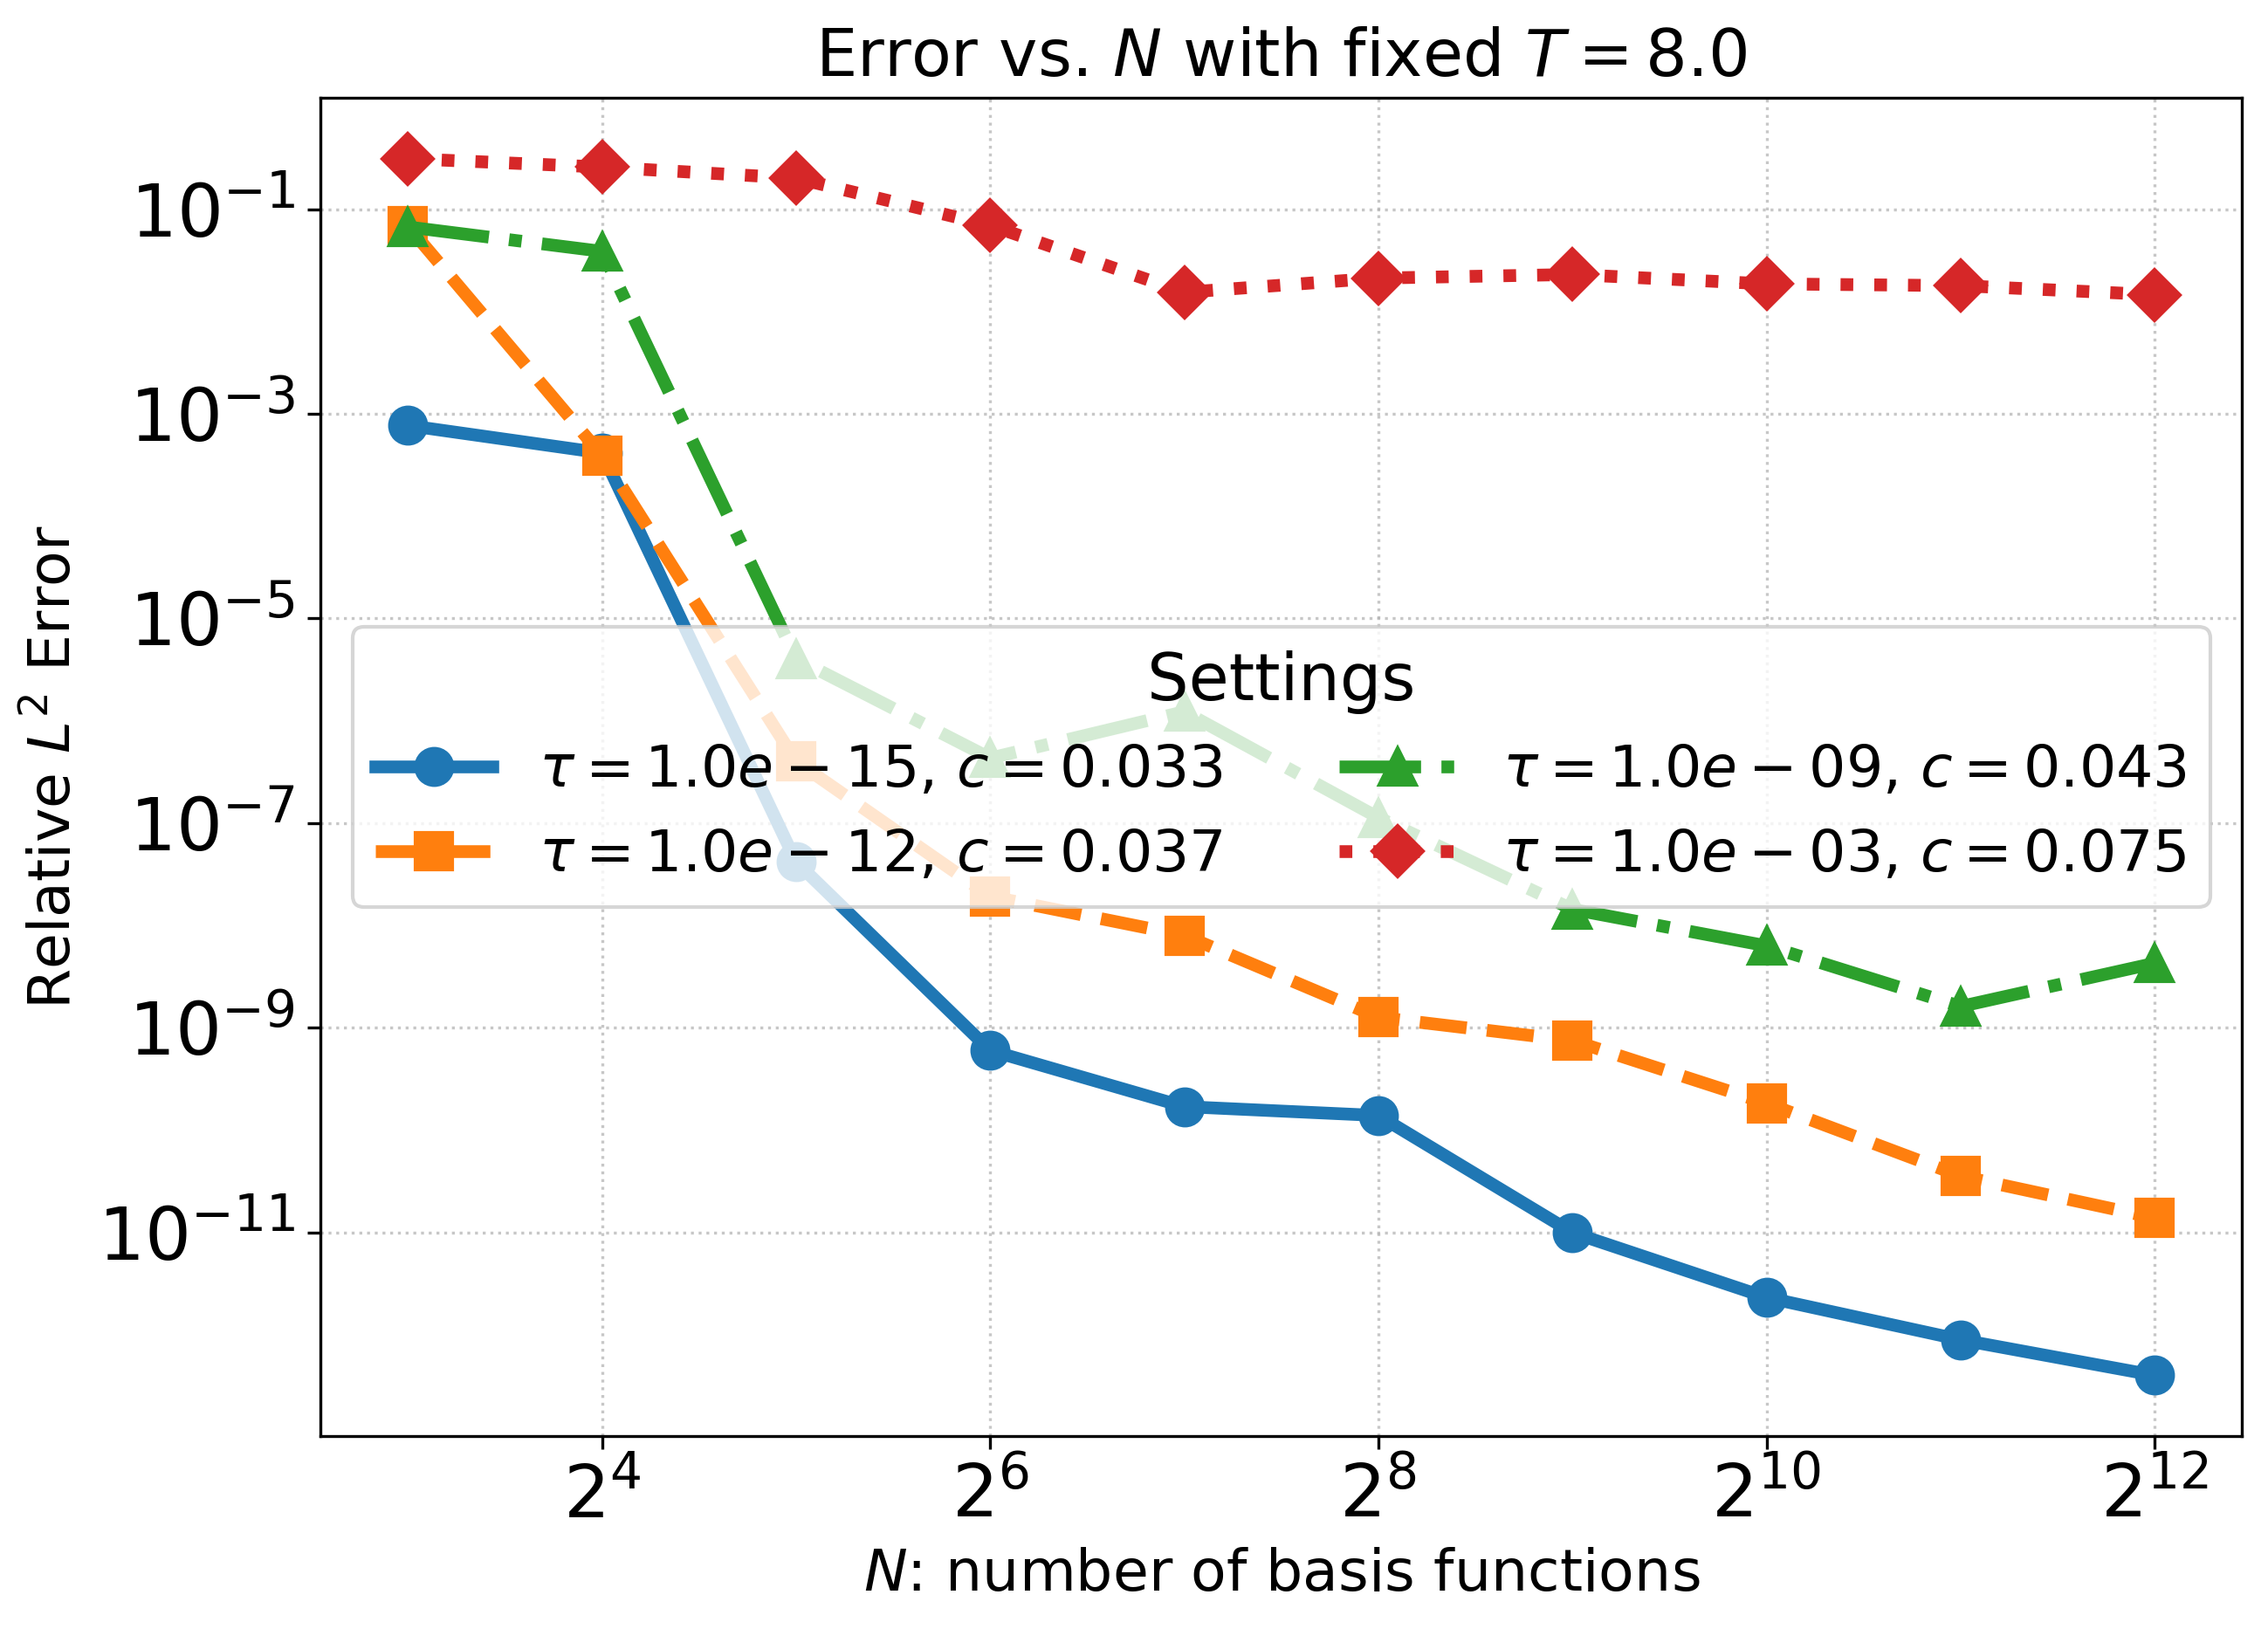

In [11]:
# =======================
# Plot E(N) vs N for each tau (T fixed)
# =======================
marker_cycle = cycle(['o', 's', '^', 'D', 'v', 'P', 'X', '*'])
linestyle_cycle = cycle(['-', '--', '-.', ':'])

plt.figure(figsize=(9, 6.5), dpi=300)

for tau in sorted(E.keys()):
    y = E[tau]
    y_plot = np.where(y > 0, y, np.nan)  # avoid nonpositive on log scale
    c_shown = Cs_used[tau]
    label = fr"$\tau={tau:.1e}$, $c={c_shown:.3f}$"
    plt.plot(
        N_values, y_plot,
        marker=next(marker_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=3.5,
        markersize=10,
        label=label
    )

plt.xscale('log', base=2)  # optional: N doubles
plt.yscale('log')
plt.xlabel(r"$N$: number of basis functions", fontsize=16)
plt.ylabel(r"Relative $L^2$ Error", fontsize=16)
plt.title(fr"Error vs. $N$ with fixed $T={T_fixed}$", fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tick_params(labelsize=20)
plt.legend(title="Settings", fontsize=16, title_fontsize=18, ncol=2, frameon=True, loc = 'center')
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig12_poisson.png')
# plt.show()